## InstaCart Dataset Analysis 

In [1]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew


# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking
# !pip install tqdm
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return '${:,.0f}'.format(x)

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



In [2]:
#IMPORT ALL CSVS as df's first 
order_products_prior = pd.read_csv('Instacart_Marketbasketanalysis_dataset/order_products__prior.csv')

order_products_train = pd.read_csv('Instacart_Marketbasketanalysis_dataset/order_products__train.csv')

aisles = pd.read_csv('Instacart_Marketbasketanalysis_dataset/aisles.csv')

departments = pd.read_csv('Instacart_Marketbasketanalysis_dataset/departments.csv')

products = pd.read_csv('Instacart_Marketbasketanalysis_dataset/products.csv')


In [3]:
# Merge all csv based on keys

#1) CONCAT products_prior and products_train 
order_products = pd.concat([order_products_prior, order_products_train], ignore_index=True)
#note -> products_prior = all historical orders EXCEPT for last customer order
# products_train = ONE MOST RECENT ORDER of each customer (used for training model on target variable y = reorder or not!)

#2) MERGE other files using common ID
df = order_products.merge(products, on='product_id')
df = df.merge(aisles, on='aisle_id')
df = df.merge(departments, on='department_id')

In [4]:
df

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry
...,...,...,...,...,...,...,...,...,...
33819101,3421063,14233,3,1,Natural Artesian Water,115,7,water seltzer sparkling water,beverages
33819102,3421063,35548,4,1,Twice Baked Potatoes,13,20,prepared meals,deli
33819103,3421070,35951,1,1,Organic Unsweetened Almond Milk,91,16,soy lactosefree,dairy eggs
33819104,3421070,16953,2,1,Creamy Peanut Butter,88,13,spreads,pantry


# 1) EDA of  Dataset: PRE-PROCESSING

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 9 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   order_id           int64 
 1   product_id         int64 
 2   add_to_cart_order  int64 
 3   reordered          int64 
 4   product_name       object
 5   aisle_id           int64 
 6   department_id      int64 
 7   aisle              object
 8   department         object
dtypes: int64(6), object(3)
memory usage: 2.3+ GB


NOTE 

- order_id is done PER ROW = so sum() is TOTAL PRODUCTS in order
- add_to_cart_order = sequence of items added to cart ex) 4 is 4th item added
- reordered = tracker for if customer purchased again (1 or 0)

In [6]:
#PREPROCESSING HERE


#1) Handling Missing Values
df.isna().sum()          # none here 


#2) Categorical Variables Consistent Formats
            # convert aisle and department to category efficient memory
df['aisle'] = df['aisle'].astype('category')
df['department'] = df['department'].astype('category')



In [7]:
#3) Standardize Units
            #none here

#4) Remove Duplicates 
df.duplicated().sum()       #none here

#5) Filter Unrealistic Values
           #none here

#6) Detect Outliers 
df['add_to_cart_order'].max()

145

# 2) EDA of Dataset: Univariate Analysis 


59.01% of products were reordered, and 40.99% were not reordered


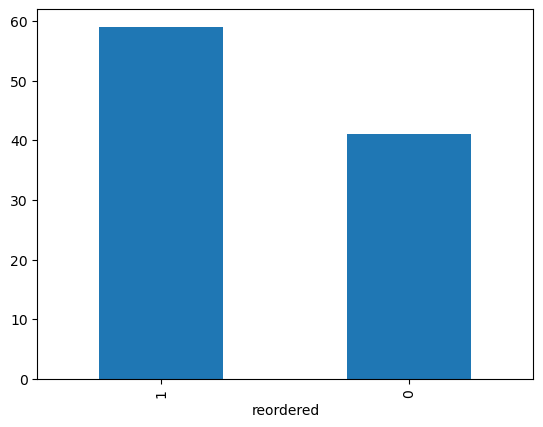

In [8]:
#RE-ORDER frequency 
freq = df['reordered'].value_counts(normalize=True)
freq = freq*100
print(f'{freq.iloc[0]:.2f}% of products were reordered, and {freq.iloc[1]:.2f}% were not reordered')

freq.plot(kind='bar');

#NOTED- can't use freq[0] because there is already a label of 0 so will output 41% not 59% wrong

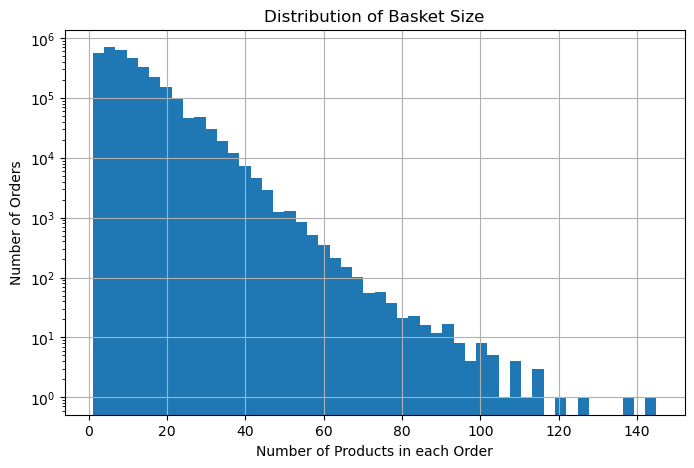

In [9]:
#distribution of products per order 
itemsperorder = df.groupby('order_id').size()

plt.figure(figsize=(8,5))
itemsperorder.hist(bins=50)
plt.xlabel("Number of Products in each Order")
plt.ylabel("Number of Orders")
plt.yscale('log')
plt.title("Distribution of Basket Size")
plt.show()


product_name
Organic Whole Milk        142813
Limes                     146660
Strawberries              149445
Large Lemon               160792
Organic Avocado           184224
Organic Hass Avocado      220877
Organic Baby Spinach      251705
Organic Strawberries      275577
Bag of Organic Bananas    394930
Banana                    491291
Name: count, dtype: int64

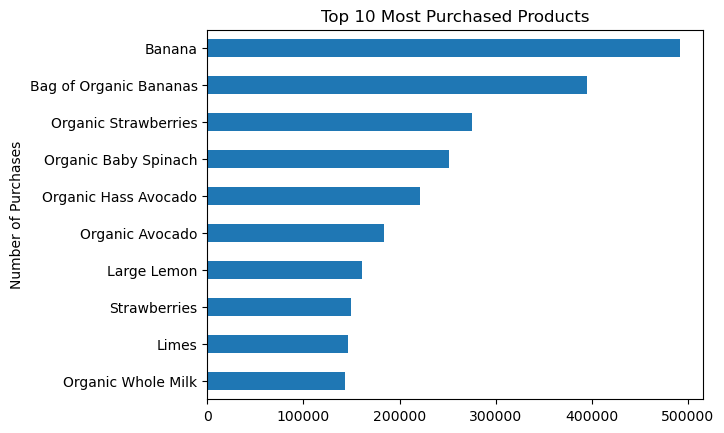

In [10]:
#Most Popular Products uSE THIS
top_products = df['product_name'].value_counts().head(10)
display(top_products.sort_values())
top_products.sort_values().plot(kind='barh')

plt.xticks()
plt.ylabel("Number of Purchases")
plt.title("Top 10 Most Purchased Products")

plt.show()

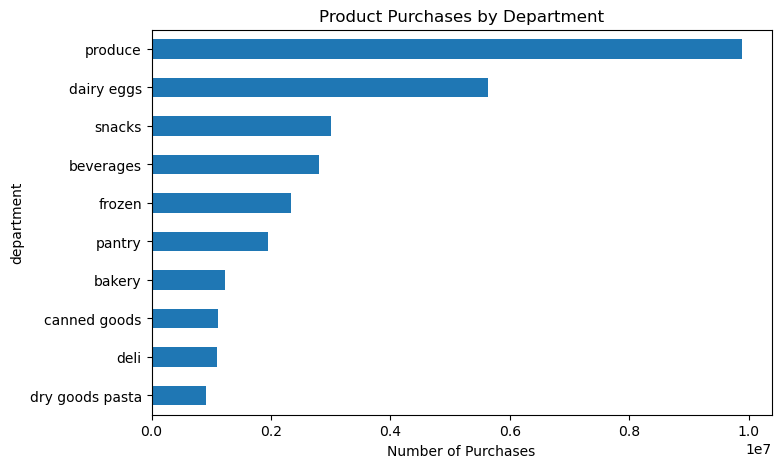

In [11]:
#Most Popular Departments
popdepts = df['department'].value_counts().head(10)

plt.figure(figsize=(8,5)) 
popdepts.sort_values().plot(kind='barh')
plt.xlabel("Number of Purchases")
plt.title("Product Purchases by Department")
plt.show()

In [12]:
#STATISTICS -> mean, median, min, max of how many products in each order
df['order_id'].value_counts().describe()

count    3.346083e+06
mean     1.010707e+01
std      7.542326e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: count, dtype: float64

# 3) EDA of Dataset: Bivariate Analysis 

<Axes: >

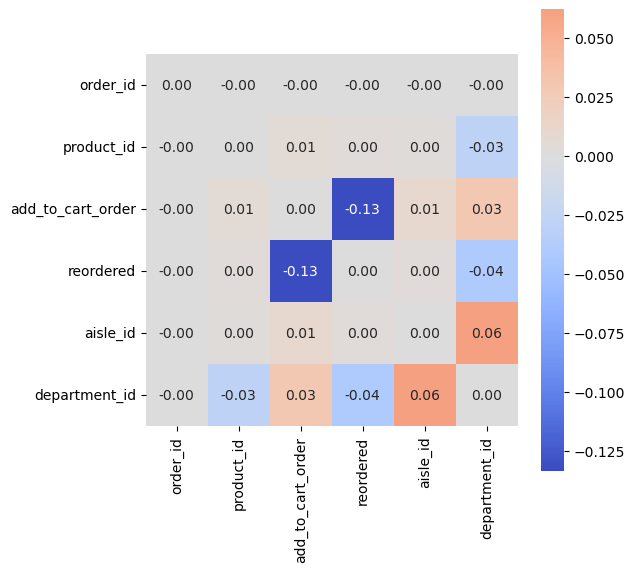

In [13]:
#Heatmap 
plt.figure(figsize=(6,6))
corr = df.corr(numeric_only=True)
np.fill_diagonal(corr.values, 0) #takes in 1D array 

sns.heatmap(corr, cmap='coolwarm', annot=True, center=0, fmt='.2f', square=True)

In [14]:
#Product popularity by department -> most ordered product by department 
pop_dept = df.groupby(['department','product_name'],observed=False).size()
topprod = pop_dept.groupby(level=0).nlargest(1)
topprod

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_81383/243136170.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  topprod = pop_dept.groupby(level=0).nlargest(1)


department       department       product_name                                    
alcohol          alcohol          Sauvignon Blanc                                       8541
babies           babies           Baby Food Stage 2 Blueberry Pear & Purple Carrot      9103
bakery           bakery           100% Whole Wheat Bread                               63114
beverages        beverages        Sparkling Water Grapefruit                           79245
breakfast        breakfast        Honey Nut Cheerios                                   27959
bulk             bulk             Dried Mango                                          10596
canned goods     canned goods     Organic Black Beans                                  39577
dairy eggs       dairy eggs       Organic Whole Milk                                  142813
deli             deli             Original Hummus                                      74172
dry goods pasta  dry goods pasta  Marinara Sauce                                

department
dairy eggs    0.670161
beverages     0.653651
produce       0.650521
bakery        0.628381
deli          0.608130
pets          0.602557
babies        0.577680
bulk          0.577090
snacks        0.574464
alcohol       0.571221
Name: reordered, dtype: float64

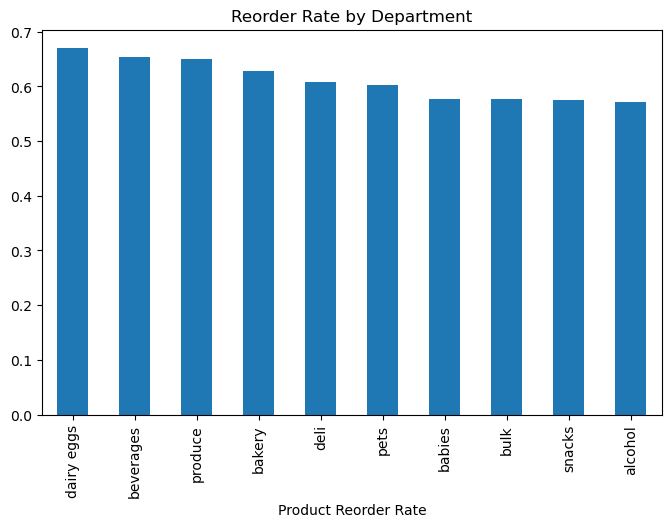

In [15]:
#Reorder behavior by department -> which depts have highest reorder rates

reorder_dept = df.groupby('department',observed=False)['reordered'].mean().sort_values(ascending=False).head(10)
#NOTED - using .mean = groupedby for all values in that department, compute rate how many were reordered 
display(reorder_dept)
plt.figure(figsize=(8,5))
reorder_dept.plot(kind='bar')
plt.xlabel('Product Reorder Rate')
plt.title("Reorder Rate by Department")
plt.show()

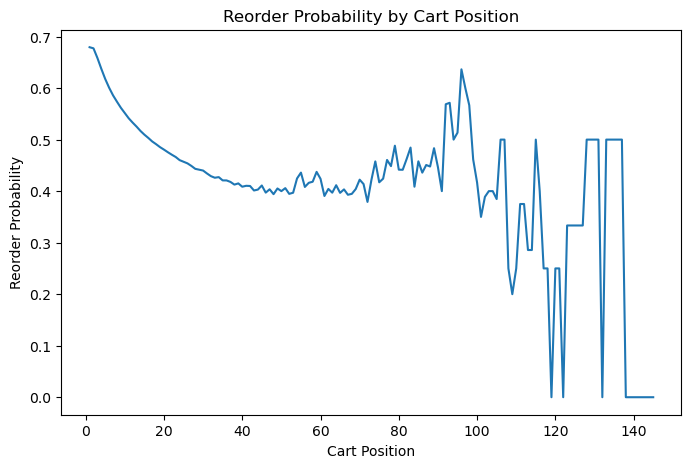

In [16]:
#Reorder probability by basket position -> chances of reorder item BASED ON WHEN added to cart
cart_reorder = df.groupby('add_to_cart_order')['reordered'].mean()
cart_reorder

plt.figure(figsize=(8,5))
cart_reorder.plot()
plt.xlabel("Cart Position")
plt.ylabel("Reorder Probability")
plt.title("Reorder Probability by Cart Position")
plt.show()

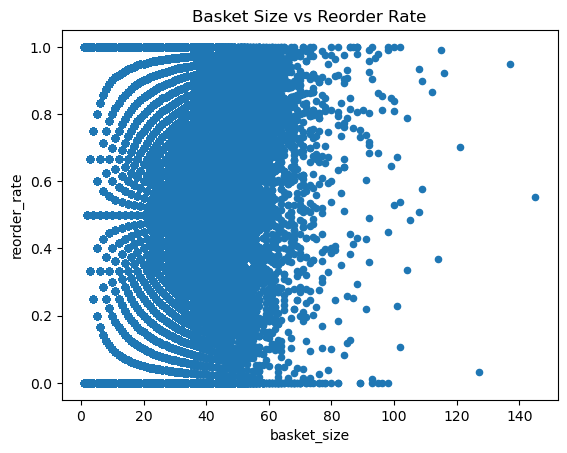

In [17]:
#cart size vs reorder rate -> do larger carts correlate with higher reorder rates
basket_size = df.groupby('order_id').size()     #shows each cart and how many orders in it
basket_reorder = df.groupby('order_id')['reordered'].mean() #shows each cart and WHAT % of items were reorders

basket_df = pd.DataFrame({
    'basket_size': basket_size,
    'reorder_rate': basket_reorder
})

basket_df.plot.scatter(x='basket_size', y='reorder_rate')
plt.title("Basket Size vs Reorder Rate")
plt.show()

In [18]:
#Plots - scatter matrix, line, waterfall, area, pair

#Box plot of outcomes by category 

#Correlation matrix, heatmap!


#Crosstab table or grouped means


# 4) Conclusions: Expected or Unexpected
- explained in essay


# 5) Conclusions: Datasets Disqualified  
- explained in essay


# 6) Conclusions: Supervised or Unsupervised analysis   
- explained in essay


<br><br>
---
# 📊 Milestone 4 START Multivariate Analysis, Modeling, Etc.



---


<Axes: >

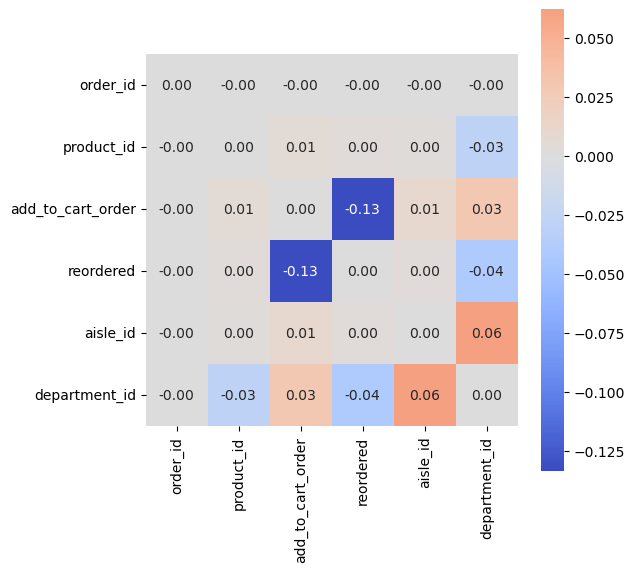

In [19]:
#1) Multivariate Analysis
df_num = df.select_dtypes(include='number')

#heatmap, bubble, PCA, pairplot, etc.

#Heatmap 
plt.figure(figsize=(6,6))
corr = df.corr(numeric_only=True)
np.fill_diagonal(corr.values, 0) #takes in 1D array 

sns.heatmap(corr, cmap='coolwarm', annot=True, center=0, fmt='.2f', square=True)


## Aggregating Products first (df_prod)

In [20]:
#df of average reorder rates and total purchases (USE THIS AS FIGURE)
df_prod = df.groupby('product_name').agg({
    'reordered' : 'mean',
    'order_id' : 'count'
}).rename(columns={'order_id':'purchases'}).reset_index()
display(
    df_prod.sort_values(by='purchases', ascending=False).head(10),
    df_prod.sort_values(by='reordered', ascending=False).head(10)
)


,product_name,reordered,purchases
3677,Banana,0.845051,491291
3472,Bag of Organic Bananas,0.833755,394930
31923,Organic Strawberries,0.778178,275577
28843,Organic Baby Spinach,0.774474,251705
30300,Organic Hass Avocado,0.797607,220877
28807,Organic Avocado,0.761410,184224
22415,Large Lemon,0.697659,160792
42908,Strawberries,0.699843,149445
23422,Limes,0.681863,146660
32481,Organic Whole Milk,0.831045,142813


,product_name,reordered,purchases
37379,Raw Veggie Wrappers,0.942029,69
39870,Serenity Ultimate Extrema Overnight Pads,0.933333,90
28415,Orange Energy Shots,0.923077,13
8537,Chocolate Love Bar,0.921569,102
41723,Soy Powder Infant Formula,0.914286,35
40458,Simply Sleep Nighttime Sleep Aid,0.911111,45
13844,"Energy Shot, Grape Flavor",0.909091,22
38793,Russian River Valley Reserve Pinot Noir,0.900000,30
3832,Bars Peanut Butter,0.898551,69
41712,Soy Crisps Lightly Salted,0.895522,67


Text(0.5, 1.0, 'Product Popularity vs. Reorder Rate')

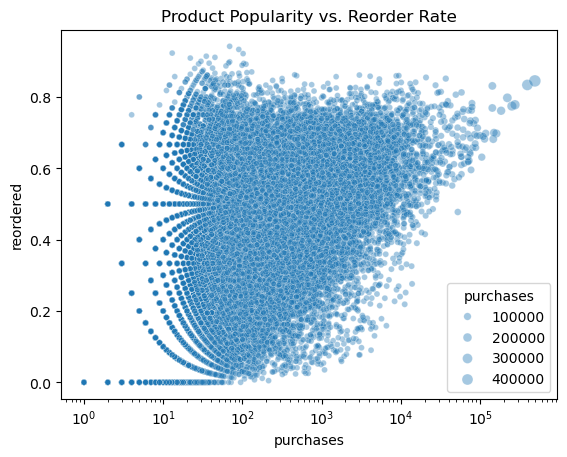

In [21]:
#Bubble Plot
sns.scatterplot(
    data=df_prod,
    x='purchases',
    y='reordered',
    size='purchases',
    alpha=0.4
)
plt.xscale('log')
plt.title('Product Popularity vs. Reorder Rate')

In [22]:
#Bubble Plot sorted by department color     #OR THIS ONE FOR FIGURE
df_dept = df.groupby('department').agg(
    purchases =('order_id', 'count'),
    reorder_rate=('reordered','mean'),
    unique_products=('product_id','nunique')).reset_index()

df_dept

/var/folders/8l/th8d2l4x61qfsy3grnlp019h0000gn/T/ipykernel_81383/1650359133.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_dept = df.groupby('department').agg(


,department,purchases,reorder_rate,unique_products
0,alcohol,159294,0.571221,1054
1,babies,438743,0.577680,1081
2,bakery,1225181,0.628381,1516
3,beverages,2804175,0.653651,4364
4,breakfast,739069,0.561351,1114
5,bulk,35932,0.577090,38
6,canned goods,1114857,0.458639,2092
7,dairy eggs,5631067,0.670161,3449
8,deli,1095540,0.608130,1322
9,dry goods pasta,905340,0.462220,1858


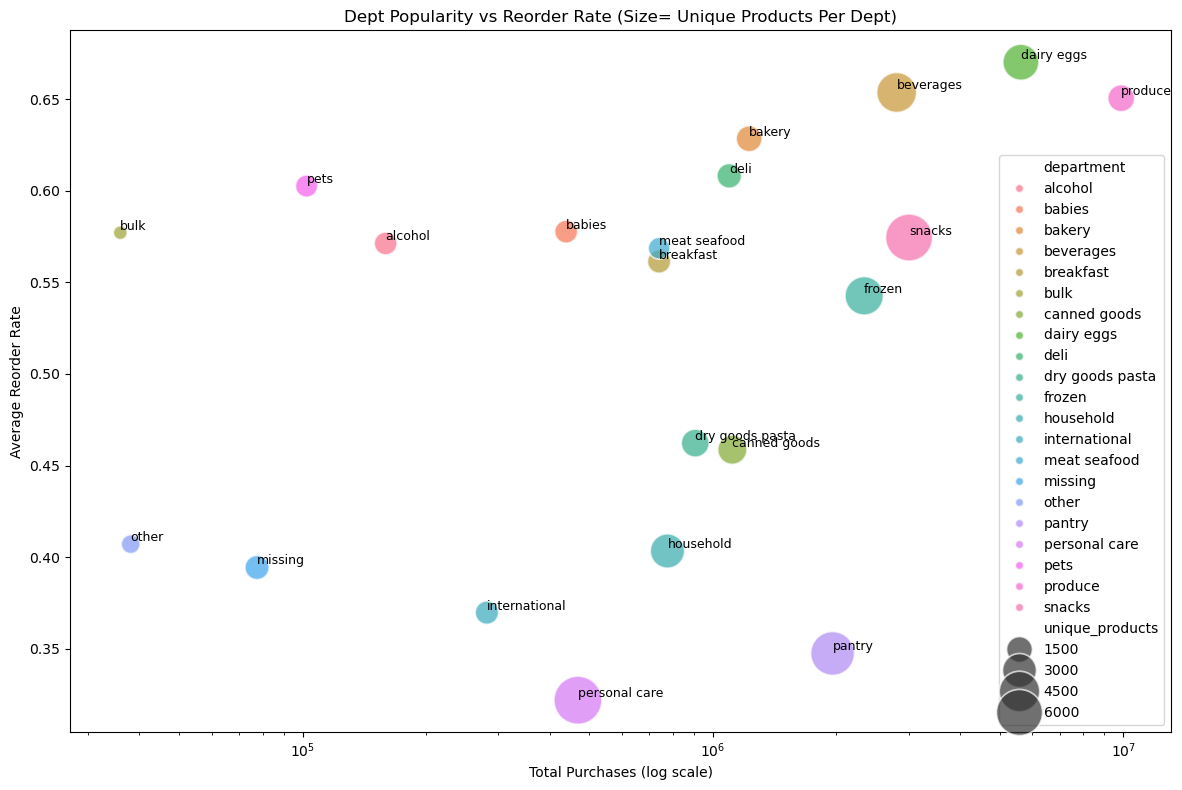

In [23]:
#Plot df_dept       (use figure)
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=df_dept,
    x='purchases',
    y='reorder_rate',
    size='unique_products',
    hue='department',
    sizes=(100, 1200),
    alpha=0.7
)

#labels 
for _, row in df_dept.iterrows():   #goes row by row
    plt.text(
        row['purchases'], #x-coordinate
        row['reorder_rate'], #y-coordinate
        row['department'],  #what text to show
        fontsize=9,
        ha='left',
        va='bottom'
    )


plt.xscale('log')

plt.title("Dept Popularity vs Reorder Rate (Size= Unique Products Per Dept)")
plt.xlabel("Total Purchases (log scale)")
plt.ylabel("Average Reorder Rate")
plt.tight_layout()
plt.show()

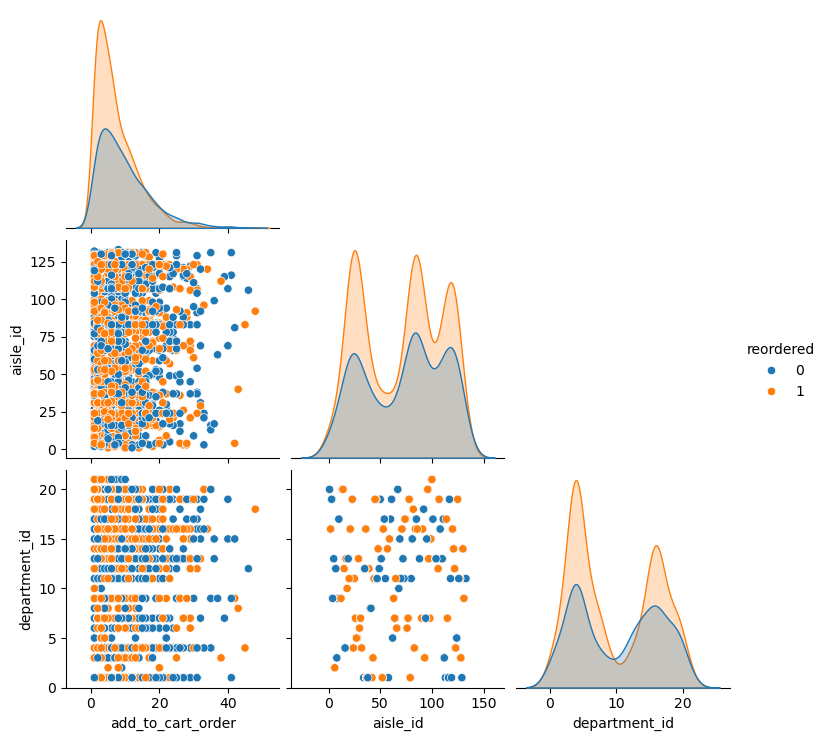

In [24]:
#Pairplot
features = [
'add_to_cart_order',
'aisle_id',
'department_id',
'reordered'
]

sns.pairplot(df[features].sample(3000), hue='reordered', corner=True)

In [25]:
#ANOTHER EDA TABLE -> PROBABILITIES with product names       !! useful!
table = (
    df.groupby('product_id')
      .agg(
          reorder_rate=('reordered','mean'),
          avg_cart_pos=('add_to_cart_order','mean')
      )
)
merged = table.merge(df[['product_id','product_name']], on='product_id')
merged.drop_duplicates()

,product_id,reorder_rate,avg_cart_pos,product_name
0,1,0.614627,5.845954,Chocolate Sandwich Cookies
1928,2,0.138298,10.138298,All-Seasons Salt
2022,3,0.738516,6.374558,Robust Golden Unsweetened Oolong Tea
2305,4,0.458689,9.472934,Smart Ones Classic Favorites Mini Rigatoni Wit...
2656,5,0.625000,6.375000,Green Chile Anytime Sauce
...,...,...,...,...
33818814,49684,0.111111,4.333333,"Vodka, Triple Distilled, Twist of Vanilla"
33818823,49685,0.122449,9.571429,En Croute Roast Hazelnut Cranberry
33818872,49686,0.700787,7.433071,Artisan Baguette
33818999,49687,0.428571,7.071429,Smartblend Healthy Metabolism Dry Cat Food


In [26]:
#make df_pca first 

# product-level aggregation
df_pca = df.groupby(['product_id', 'department_id', 'aisle_id']).agg(
    total_purchases=('order_id', 'count'),  #new feature of total purchases
    reorder_rate=('reordered', 'mean'),     #new feature of reorder rate (average)
    avg_cart_position=('add_to_cart_order', 'mean') #new feature of average cart position of item
).reset_index()

# log-transform skewed count
df_pca['log_total_purchases'] = np.log1p(df_pca['total_purchases'])

# select PCA features
pca_features = [
    'log_total_purchases',
    'reorder_rate',
    'avg_cart_position',
    'aisle_id',
    'department_id'
]

X_pca = df_pca[pca_features].copy()


In [27]:
#run PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA()
X_scores = pca.fit_transform(X_scaled)

#explained variance 
explained_var = pd.Series(
    pca.explained_variance_ratio_,
    index=[f'PC{i}' for i in range(1, len(pca_features)+1)]
)

print(explained_var)
print("Cumulative explained variance:")
print(explained_var.cumsum())

PC1    0.332710
PC2    0.224600
PC3    0.185168
PC4    0.175786
PC5    0.081736
dtype: float64
Cumulative explained variance:
PC1    0.332710
PC2    0.557310
PC3    0.742479
PC4    0.918264
PC5    1.000000
dtype: float64


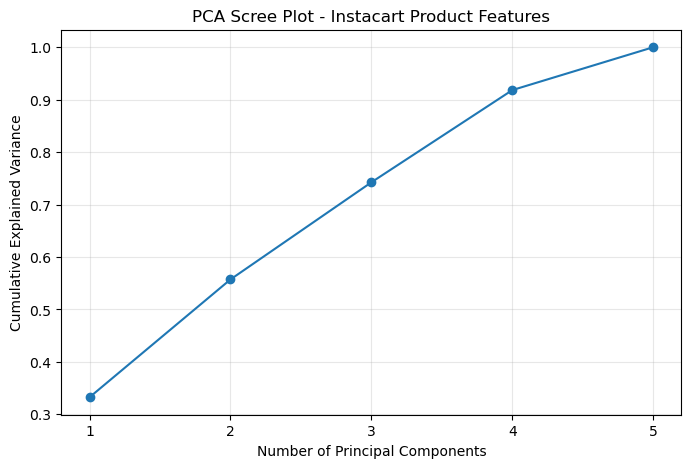

                          PC1       PC2       PC3       PC4       PC5
log_total_purchases  0.644485  0.175581  0.265449 -0.157290 -0.677205
reorder_rate         0.676220  0.095167  0.142104  0.035418  0.715697
avg_cart_position   -0.330149  0.333399  0.666894 -0.555547  0.162684
aisle_id             0.030497  0.643580 -0.649791 -0.401816  0.034510
department_id       -0.132050  0.659367  0.205832  0.709872 -0.038910


In [28]:
#Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_features)+1), explained_var.cumsum(), marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot - Instacart Product Features")
plt.xticks(range(1, len(pca_features)+1))
plt.grid(alpha=0.3)
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[f'PC{i}' for i in range(1, len(pca_features)+1)]
)

print(loadings)

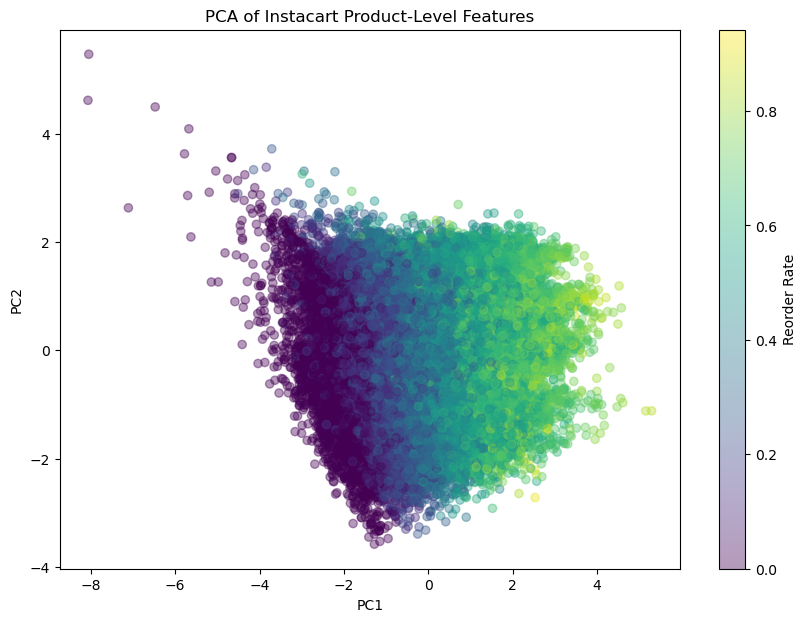

In [29]:
#PC1 vs PC2 scatter plot, colored by reorder rate 
df_scores = pd.DataFrame(X_scores[:, :2], columns=['PC1', 'PC2'])
df_scores['reorder_rate'] = df_pca['reorder_rate']

plt.figure(figsize=(10,7))
scatter = plt.scatter(
    df_scores['PC1'],
    df_scores['PC2'],
    c=df_scores['reorder_rate'],
    alpha=0.4
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Instacart Product-Level Features")
plt.colorbar(scatter, label='Reorder Rate')
plt.show()

# START OF MODELING

In [30]:
#2) Modeling 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [31]:
#2a) Logistic Regression (predict reordered 1 or 0)
features = [
    'add_to_cart_order',
    'product_id',
    'aisle_id',
    'department_id'
]
target = 'reordered'

#create df_model
df_model = df[features + [target]].dropna().copy()
df_model = df_model.sample(20000)
X = df_model[features]
y = df_model[target]

#Train,test,split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

#Make Logistic Regression
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=0
    )
)
#fit
log_model.fit(X_train,y_train)

#predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

#metrics
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

===== Logistic Regression =====
Accuracy : 0.59725
Precision: 0.6057987175913019
Recall   : 0.9168776371308017
F1 Score : 0.7295618599966426
ROC AUC: 0.5854462737179985


In [32]:
#2b) Random Forest w/ CV, hyperparameter tuning, metrics

#create rf
rf = RandomForestClassifier(
    random_state=0,
    n_jobs=-1
)

#param_dist
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
#create RS-CV 
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=0,
    n_jobs=1,
    verbose=1
)
#fit RS-CV to find best params
rf_search.fit(X_train,y_train)

print("\nBest RF Params:")
print(rf_search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best RF Params:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}


In [33]:
#Now PREDICT using best model and the test set
best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

print("\n===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

#Feature Importance 
importances = pd.Series(
    best_rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importance:")
print(importances)


===== Random Forest =====
Accuracy : 0.616
Precision: 0.6244776119402985
Recall   : 0.8827004219409282
F1 Score : 0.7314685314685314
ROC AUC  : 0.621589526546038

Feature Importance:
add_to_cart_order    0.374698
department_id        0.309445
aisle_id             0.233179
product_id           0.082678
dtype: float64


In [34]:
#Model Comparison 
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print("\n===== Model Comparison for Instacart Dataset =====")
results


===== Model Comparison for Instacart Dataset =====


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.59725,0.729562,0.585446
1,Random Forest,0.61600,0.731469,0.621590


<br><br>
---
# 📊 Mod C1 CAPSTONE Milestone 1 START -> More Modeling



---

In [35]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


## X = linregdf[['avg_cart_pos', 'total_orders', 'aisle_id', 'department_id']
## y = linregdf['reorder_rate']


## for logistic reg = 
- features = [
    'add_to_cart_order',
    'product_id',
    'aisle_id',
    'department_id'
]
- target = 'reordered'

## Week 1 - Linear Regression 


In [36]:
#predict reorder rate based on product id, aisle id, dept id, cart position

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


# aggregate to product level
linregdf = (
    df.groupby('product_id')
      .agg(
          reorder_rate=('reordered', 'mean'), #find avg value of reordered per product, CHANGE FROM BINARY
          avg_cart_pos=('add_to_cart_order', 'mean'), #find avg cart position per product 
          total_orders=('product_id', 'size'),  #new column, sum of each item
          aisle_id=('aisle_id', 'first'),        #because each product has 1 unique aisle/dept id
          department_id=('department_id', 'first')
      )
      .reset_index()
)
display(linregdf)

# X and y
X = linregdf[
    ['avg_cart_pos', 'total_orders', 'aisle_id', 'department_id']
]
y = linregdf['reorder_rate']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# numeric and categorical columns
numeric_features = ['avg_cart_pos', 'total_orders']
categorical_features = ['aisle_id', 'department_id']

# preprocessing,        ONEHOTENCODE the categorical features here 
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

# fit model
model.fit(X_train, y_train)

# predict X_test
y_pred = model.predict(X_test)

# results
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

,product_id,reorder_rate,avg_cart_pos,total_orders,aisle_id,department_id
0,1,0.614627,5.845954,1928,61,19
1,2,0.138298,10.138298,94,104,13
2,3,0.738516,6.374558,283,94,7
3,4,0.458689,9.472934,351,38,1
4,5,0.625000,6.375000,16,5,13
...,...,...,...,...,...,...
49680,49684,0.111111,4.333333,9,124,5
49681,49685,0.122449,9.571429,49,42,1
49682,49686,0.700787,7.433071,127,112,3
49683,49687,0.428571,7.071429,14,41,8


RMSE: 0.1640201386220719
R2: 0.37121518098514406


In [88]:
linregdf

,product_id,reorder_rate,avg_cart_pos,total_orders,aisle_id,department_id,position_total_interaction
0,1,0.614627,5.845954,1928,61,19,11271.0
1,2,0.138298,10.138298,94,104,13,953.0
2,3,0.738516,6.374558,283,94,7,1804.0
3,4,0.458689,9.472934,351,38,1,3325.0
4,5,0.625000,6.375000,16,5,13,102.0
...,...,...,...,...,...,...,...
49680,49684,0.111111,4.333333,9,124,5,39.0
49681,49685,0.122449,9.571429,49,42,1,469.0
49682,49686,0.700787,7.433071,127,112,3,944.0
49683,49687,0.428571,7.071429,14,41,8,99.0


ANSWER ->

Linear regression performed very poorly (r2 = 0.37) due to the dataset features being suitable for logistic regression given the binary "reorder" variable. Instead, a regular linear regression was attempted to predict reorder rate using average cart position, total orders, and aisle and department id. 

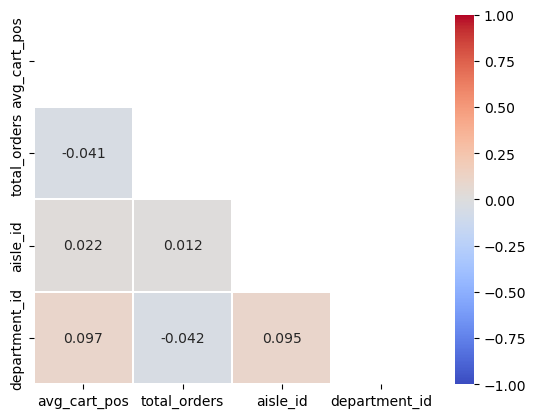

In [37]:
# Multicollinearity 
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0,
            linewidths=0.3, vmin=-1, vmax=1)
plt.show()

#ANSWER -> very low correlations, less than 1% correlation

In [38]:
#Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

#create VIF model design matrix
linregdf['position_total_interaction'] = (
    linregdf['avg_cart_pos']*linregdf['total_orders']
)

X_vif = linregdf.drop(columns=['reorder_rate','position_total_interaction'])

#Calculate VIF for all variables
vif_df = pd.DataFrame()

vif_df['Feature'] = X_vif.columns   #creates column with list of columns

vif_df['VIF']= [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]
vif_df
#ANSWER --> all under 10 so less than moderate collinearity which is good

,Feature,VIF
0,product_id,3.466480
1,avg_cart_pos,6.741975
2,total_orders,1.017769
3,aisle_id,3.724857
4,department_id,4.591457


## Week 2 - Lasso, Ridge, Elastic Net


In [39]:
#1) LASSO MODEL - start

#MODEL -> Lasso Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

lasso_model = make_pipeline(
    StandardScaler(),
    LassoCV(cv=5, random_state=0, max_iter=10000)
)

# CV RMSE
cv_scores = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Lasso Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
lasso_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = lasso_model.named_steps['lassocv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = lasso_model.predict(X_test)

#Metrics
l_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
l_r2 = r2_score(y_test, y_pred)
print("Lasso Regression Test RMSE:", l_rmse)
print("Lasso Regression Test R2:", l_r2)




Lasso Regression CV RMSE: 0.19966529190346463
best alpha: 0.0005191109738990061
Lasso Regression Test RMSE: 0.19967004703493543
Lasso Regression Test R2: 0.0681767570266828


In [40]:
#2) RIDGE REGRESSION MODEL - start

#MODEL -> Ridge Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4,4,100),cv=5)
        #! FIND BEST ALPHA on log scale so 100 values between 10^-4 and 10^4 
)

# CV RMSE
cv_scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("Ridge Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
ridge_model.fit(X_train, y_train)

#FIND BEST ALPHA value -> using .named_steps
bestalpha = ridge_model.named_steps['ridgecv'].alpha_
print('best alpha:', bestalpha)
#Predict using X_test
y_pred = ridge_model.predict(X_test)

#Metrics
r_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_r2 = r2_score(y_test, y_pred)
print("Ridge Regression Test RMSE:", r_rmse)
print("Ridge Regression Test R2:", r_r2)


Ridge Regression CV RMSE: 0.1996624391370254
best alpha: 1072.2672220103254
Ridge Regression Test RMSE: 0.19968962551209726
Ridge Regression Test R2: 0.06799400979156511


In [41]:
#3) ELASTIC NET REGRESSION MODEL - start

#MODEL -> elastic net Regression with pipeline for scaling
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

elastic_model = make_pipeline(
    StandardScaler(),
    ElasticNetCV(alphas=np.logspace(-4,4,100),
                 l1_ratio=[0.1,0.5,0.7,0.9,1.0],
                #! HERE FIND BEST RATIO (0.0 L2 ridge vs. 1.0 L1 lasso)
                 cv=5)
    
)

# CV RMSE
cv_scores = cross_val_score(
    elastic_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)
print("ElasticNet Regression CV RMSE:", -cv_scores.mean())

#Compare to TEST performance
elastic_model.fit(X_train, y_train)

#FIND BEST L1 RATIO value -> using .named_steps
bestratio = elastic_model.named_steps['elasticnetcv'].l1_ratio_
print('best ratio:', bestratio)
            #note = best ratio = 0.1 (closer to R2 ridge)
#Predict using X_test
y_pred = elastic_model.predict(X_test)

#Metrics
e_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
e_r2 = r2_score(y_test, y_pred)
print("ElasticNet Regression Test RMSE:", e_rmse)
print("ElasticNet Regression Test R2:", e_r2)


ElasticNet Regression CV RMSE: 0.1996667188568388
best ratio: 0.1
ElasticNet Regression Test RMSE: 0.19967751779461917
ElasticNet Regression Test R2: 0.06810702641007704


In [42]:
comparisondf = pd.DataFrame({
"Lasso":[l_rmse, l_r2],
"Ridge":[r_rmse, r_r2],
'ElasticNet': [e_rmse, e_r2]
},index=['RMSE', 'R2'])
comparisondf

,Lasso,Ridge,ElasticNet
RMSE,0.199670,0.199690,0.199678
R2,0.068177,0.067994,0.068107


## Week 3 - Fwd/Back Selection, PCR, PLSR


In [43]:
#3A1) Fwd Selection
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

sfs_for = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='forward',
    cv=5
)

sfs_for.fit(X, y)

selected_features = X.columns[sfs_for.get_support()]
print(selected_features)


Index(['avg_cart_pos', 'total_orders'], dtype='object')


In [44]:
#3A2) Backward Selection
sfs_back = SequentialFeatureSelector(
    lr,
    n_features_to_select='auto',
    direction='backward',
    cv=5
)

#fit model
sfs_back.fit(X,y)
selected_features = X.columns[sfs_back.get_support()]
print(selected_features)

Index(['avg_cart_pos', 'total_orders'], dtype='object')


In [45]:
#3B) PCR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

#create pcr PIPELINE
pcr = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2)),   #keep only top 2 PCs
    ('lr', LinearRegression()) 
])

pcr.fit(X_train, y_train) #lin reg fits Y ~ PC1 + PC2

y_pred = pcr.predict(X_test)

print("PCR R2:", r2_score(y_test, y_pred))

PCR R2: 0.06045759410518092


In [46]:
#Explained Variance Ratio for PC's
pca = PCA()
pca.fit(StandardScaler().fit_transform(X))

print(pca.explained_variance_ratio_)

[0.28990049 0.25506774 0.23706789 0.21796388]


In [47]:
#3C) PLSR
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=2)

pls.fit(X_train, y_train)

y_pred = pls.predict(X_test)

print(
    "PLSR R2:",
    r2_score(y_test, y_pred)
)

PLSR R2: 0.06854568036458575


## Week 4 - Logistic Regression, Feature Scaling


In [48]:
# # this one wrong i think

# # Logistic Regression (predict reordered 1 or 0)
# features = [
#     'add_to_cart_order',
#     'product_id',
#     'aisle_id',
#     'department_id'
# ]
# target = 'reordered'

# #create df_model
# logreg_model = df[features + [target]].dropna().copy()
# X = logreg_model[features]
# y = logreg_model[target]

# #Train,test,split
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.20,
#     random_state=0,
#     stratify=y
# )

# #Make Logistic Regression
# log_model = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(
#         max_iter=1000,
#         random_state=0
#     )
# )
# #fit model
# log_model.fit(X_train,y_train)

# #predictions on X_test
# y_pred_log = log_model.predict(X_test)
# y_prob_log = log_model.predict_proba(X_test)[:,1] #returns array of probabilities for each point

# #metrics
# print("===== Logistic Regression =====")
# print("Accuracy :", accuracy_score(y_test, y_pred_log))
# print("Precision:", precision_score(y_test, y_pred_log))    #how many positive predictions were actually true pos
# print("Recall   :", recall_score(y_test, y_pred_log))   #how many true positives actually found 
# print("F1 Score :", f1_score(y_test, y_pred_log))
# print("ROC AUC:", roc_auc_score(y_test, y_prob_log))


===== Logistic Regression =====
Accuracy : 0.5980067186865651
Precision: 0.604644030747417
Recall   : 0.9208177652520425
F1 Score : 0.7299651379352159
ROC AUC: 0.5847623518886835


In [49]:
# LOGISTIC REGRESSION WITH PRODUCT HISTORY FEATURES     (1min runtime)
# Target: reordered (0 or 1)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# 1. Select the original columns
original_features = [
    'product_id',
    'add_to_cart_order',
    'aisle_id',
    'department_id'
]
target = 'reordered'

logreg_df = (
    df[original_features + [target]]
    .dropna()
    .copy()
)
# Ensure the target is stored as an integer
logreg_df[target] = logreg_df[target].astype(int)

# ------------------------------------------------------------
# 2. Split the original purchase-level data FIRST       #train_df = X_train, y_test
train_df, test_df = train_test_split(                   #test_df = y_train, y_test
    logreg_df,          # !note only pass one df here, (not X,y), so SPLITS INTO (train, test) !
    test_size=0.20,
    random_state=0,
    stratify=logreg_df[target]
)

# Create independent copies
train_df = train_df.copy()
test_df = test_df.copy()


# ------------------------------------------------------------
# 3. Calculate product statistics from training data only           (! HERE WANT TO PREVENT LEAKAGE from peek test data !)

#NEW FEATURES 1 AND 2

#CREATE NEW DF HERE -> merge it later 
product_stats = (
    train_df
    .groupby('product_id')
    .agg(
        product_order_count=('reordered', 'size'),  #counts total orders of each product
        product_reorder_sum=('reordered', 'sum')    #counts BINARY sum only =1 reordered
    )
    .reset_index()
)

# Full training-data reorder rate
# This mapping will be used for TEST rows
product_stats['product_reorder_rate'] = (   #just calculates reordered rate per product decimal value
    product_stats['product_reorder_sum']        #NEW FEATURE 1 
    / product_stats['product_order_count']      #NEW FEATUER 2
)


# ------------------------------------------------------------
# 4. Merge product statistics df into training data df 
train_df = train_df.merge(
    product_stats,
    on='product_id',
    how='left'
)


# ------------------------------------------------------------
# 5. Create leave-one-out statistics for training rows
# subtract 1 b/c current row SHOULD NOT COUNT toward its own HISTORY
# This prevents the row's own target from appearing in its feature.

train_df['product_order_count_history'] = (
    train_df['product_order_count'] - 1     #subtract 1
)

train_df['product_reorder_sum_history'] = (         #total sum of actually reordered = 1 values 
    train_df['product_reorder_sum'] - train_df[target]      #then SUBTRACT b/c we want history, so minus one row
)

#just computes the history for feature "reorder_rate"
train_df['product_reorder_rate_history'] = np.where(    #(condition, value_if_true, value_if_false)
    train_df['product_order_count_history'] > 0,    #if order count history more than 0,

    train_df['product_reorder_sum_history']     #divide sum of all =1 by total to get reorder_rate
    / train_df['product_order_count_history'],

    np.nan  #return nan if false
)


# ------------------------------------------------------------
# 6. Merge training-only product statistics into test data

test_df = test_df.merge(
    product_stats[
        [
            'product_id',
            'product_order_count',
            'product_reorder_rate'
        ]
    ],
    on='product_id',
    how='left'      #keep ALL test_df rows, merge the NEW COLUMNS OF product_stats if matching product_id
)

# Rename test columns so train and test have matching feature names
test_df = test_df.rename(
    columns={
        'product_order_count': 'product_order_count_history',
        'product_reorder_rate': 'product_reorder_rate_history'
    }
)


# ------------------------------------------------------------
# 7. Handle products without sufficient history

# Overall reorder rate from training data only
global_reorder_rate = train_df[target].mean()   #0.59 

# Training products occurring only once have no previous history
train_df['product_order_count_history'] = (
    train_df['product_order_count_history']
    .fillna(0)                                  #just fills order_count na with 0
)

train_df['product_reorder_rate_history'] = (
    train_df['product_reorder_rate_history']
    .fillna(global_reorder_rate)                #fills reorder_rate with default avg global rate 0.59
)

# Products found only in test data were unseen during training
test_df['product_order_count_history'] = (
    test_df['product_order_count_history']
    .fillna(0)                                  #same thing for test df here
)

test_df['product_reorder_rate_history'] = (
    test_df['product_reorder_rate_history']
    .fillna(global_reorder_rate)
)


#log-transform order count because it may be right-skewed
train_df['log_product_order_count'] = np.log1p(
    train_df['product_order_count_history']
)

test_df['log_product_order_count'] = np.log1p(
    test_df['product_order_count_history']
)


# ------------------------------------------------------------
# 8. Define the final model features

numeric_features = [
    'add_to_cart_order',
    'log_product_order_count',
    'product_reorder_rate_history'
]

categorical_features = [        #CATEGORY HERE e.g. aisle 20 is not "twice" aisle 10
    'aisle_id',
    'department_id'
]

model_features = numeric_features + categorical_features

#NOW CAN SPLIT 4-way x-train, y_train, x_test, y_test
X_train = train_df[model_features]
y_train = train_df[target]

X_test = test_df[model_features]
y_test = test_df[target]


# ------------------------------------------------------------
# 9. Preprocess numerical and categorical variables

preprocessor = ColumnTransformer(       #can apply preprocessing to DIFFERENT COLUMNS
    transformers=[
        (
            'numeric',
            StandardScaler(),   #scaler for numeric
            numeric_features
        ),
        (
            'categorical',
            OneHotEncoder(      #encode category IDs into binary columns e.g. dept 3 -> dept1=0, dept2=0, dept3=1
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)


# ------------------------------------------------------------
# 10. Create logistic regression pipeline

log_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('logistic_regression', LogisticRegression(max_iter=1000,random_state=0))
    ]
)


# ------------------------------------------------------------
# 11. Fit model
log_model.fit(X_train, y_train)


# ------------------------------------------------------------
# 12. Make predictions
y_pred_log = log_model.predict(X_test)

# Probability that reordered = 1
y_prob_log = log_model.predict_proba(X_test)[:, 1]


# 13. Metrics
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_log))  #AUC USES PROBABILITY y_prob_log

print("\n===== Confusion Matrix =====")
print(confusion_matrix(y_test, y_pred_log))

print("\n===== Classification Report =====")
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy : 0.6507362257611156
Precision: 0.6604576041689654
Recall   : 0.8398658305337513
F1 Score : 0.7394349263998673
ROC AUC  : 0.6799108192081427

===== Confusion Matrix =====
[[1049499 1723251]
 [ 639107 3351965]]

===== Classification Report =====
              precision    recall  f1-score   support

           0       0.62      0.38      0.47   2772750
           1       0.66      0.84      0.74   3991072

    accuracy                           0.65   6763822
   macro avg       0.64      0.61      0.60   6763822
weighted avg       0.64      0.65      0.63   6763822



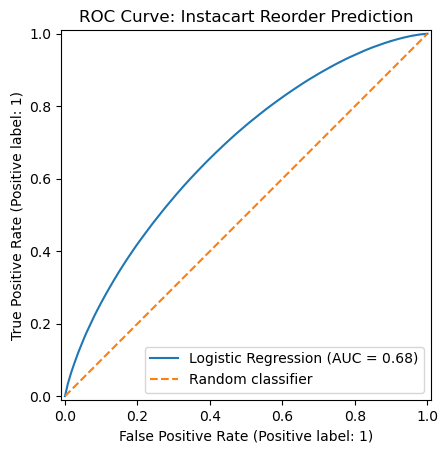

In [50]:
# 14. Plot ROC curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log,
    name='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.title('ROC Curve: Instacart Reorder Prediction')
plt.legend()
plt.show()

In [ ]:
#NAIVE MODEL - would guess 59% correct y=1 anyway !
df_model['reordered'].value_counts(normalize=True)

reordered
1    0.5924
0    0.4076
Name: proportion, dtype: float64

'accuracy:'

0.6507362257611156

'AUC:'

0.6799108192081427

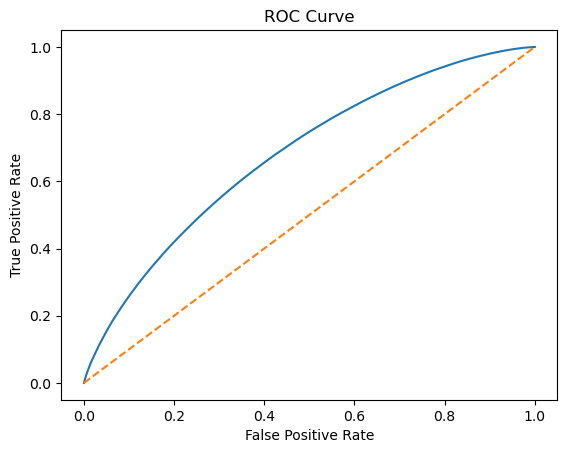

In [52]:
#GRAPH logistic model
from sklearn.metrics import roc_curve, auc

#logistic probs predict on X_test, remember 1st column is prob(Y=1), 2nd (Y=0)
probs = log_model.predict_proba(X_test)[:,1] #list of all probabilities predicted from model ! 

#create ROC curve with fpr, tpr
fpr, tpr,_ = roc_curve(y_test, probs)   #_ because dont need 3rd item thresholds

#plot ROC curve
plt.plot(fpr, tpr)

#plot y=x line
plt.plot([0,1],[0,1],'--')

#labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

#results
display(
    'accuracy:', accuracy_score(y_test,y_pred_log),
    'AUC:', roc_auc_score(y_test, probs)
)
plt.show()

## Week 5 - SVM, Kernel Trick, Regularization of Support Vector Machines


In [53]:
from sklearn.svm import SVC 
# sample smaller datasets so SVM does not use all 3 million rows (1 min runtime)
train_sample = train_df.sample(
 n=min(20000, len(train_df)), random_state=0)

test_sample = test_df.sample(
    n=min(20000, len(test_df)), random_state=0)

#NOW CAN SPLIT 4-way x_train, y_train, x_test, y_test
X_train = train_sample[model_features]
y_train = train_sample[target]

X_test = test_sample[model_features]
y_test = test_sample[target]

# SVM with linear kernel
svm_linear = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='linear', C=1, probability=True, random_state=0))
    ])

svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)
y_prob_svm = svm_linear.predict_proba(X_test)[:, 1]

print("===== Linear SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Linear SVM =====
Accuracy : 0.61875
Precision: 0.6269049858889935
Recall   : 0.8564084989718985
F1 Score : 0.7239019444545026
ROC AUC  : 0.6465857682844368


In [54]:
# SVM with RBF kernel   (1min runtime)
svm_rbf = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        probability=True,
        random_state=0
    ))
])

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("===== RBF Kernel SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rbf))
print("Precision:", precision_score(y_test, y_pred_rbf))
print("Recall   :", recall_score(y_test, y_pred_rbf))
print("F1 Score :", f1_score(y_test, y_pred_rbf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rbf))

===== RBF Kernel SVM =====
Accuracy : 0.6436
Precision: 0.6464106199252481
Recall   : 0.8594071281699794
F1 Score : 0.7378447958808385
ROC AUC  : 0.6507193047690343


In [55]:
#Regularization SVM with random search and tuning C (1 min runtime)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=0))
])

param_dist = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1]
}

svm_search = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=0,
    n_jobs=1
)

svm_search.fit(X_train, y_train)

print("Best params:", svm_search.best_params_)

Best params: {'svm__kernel': 'linear', 'svm__gamma': 0.1, 'svm__C': 0.1}


In [56]:
#now test model with best parameters    (40s runtime)
best_params = svm_search.best_params_

best_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(
        kernel=best_params['svm__kernel'],
        C=best_params['svm__C'],
        gamma=best_params['svm__gamma'],
        probability=True,
        random_state=0
    ))
])

#fit model
best_svm.fit(X_train, y_train)

#y_pred and y_prob
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

print("===== Best SVM =====")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_svm))

===== Best SVM =====
Accuracy : 0.61835
Precision: 0.6246374128247856
Recall   : 0.8671178889650446
F1 Score : 0.7261704035874439
ROC AUC  : 0.6614355463027524


## Week 6 - Decision Trees, Random Forests


In [239]:
#1) Decision Tree w/ randomized search and CV

#put decision tree inside pipeline so preprocessing is applied
dt = Pipeline([
    ('preprocessor', preprocessor),     #string names are the pipeline STEP names
    ('dt', DecisionTreeClassifier(random_state=0))
])

#a) make params

param_dist = {
    'dt__ccp_alpha': [0.0, 0.001, 0.01, 0.05, 0.1],     #double underscore b/c sklearn syntax to access parameter
    'dt__max_depth': [3, 5, 10, None],                  #from INSIDE a pipeline !
    'dt__min_samples_split': [2, 5, 10, 15],
    'dt__min_samples_leaf': [1, 2, 5, 10]
}

#b) make RS-CV
dt_search = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)

#c) fit RS-CV
dt_search.fit(X_train, y_train)

best_dt = dt_search.best_estimator_

#d) predict using RS-CV
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

#e) metrics
print("===== Decision Tree =====")
print("Best Parameters:", dt_search.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

===== Decision Tree =====
Best Parameters: {'dt__min_samples_split': 15, 'dt__min_samples_leaf': 10, 'dt__max_depth': 3, 'dt__ccp_alpha': 0.0}
Accuracy : 0.6427
Precision: 0.6588516074687631
Recall   : 0.8041466758053462
F1 Score : 0.7242842811945366
ROC AUC  : 0.6637015698957546


In [240]:
#2) random forest with randomized search
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

#put random forest inside pipeline so preprocessing is applied
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=0))
])

#make params
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 10, None],
    'rf__min_samples_split': [2, 5, 10]
}

#make RS-CV
rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)

#fit RS-CV
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

#predict using RS-CV
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

#metrics
print("===== Random Forest =====")
print("Best Parameters:", rf_search.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

===== Random Forest =====
Best Parameters: {'rf__n_estimators': 100, 'rf__min_samples_split': 10, 'rf__max_depth': None}
Accuracy : 0.6264
Precision: 0.649041873669269
Recall   : 0.7834989718985607
F1 Score : 0.7099604068007143
ROC AUC  : 0.6476457046972022


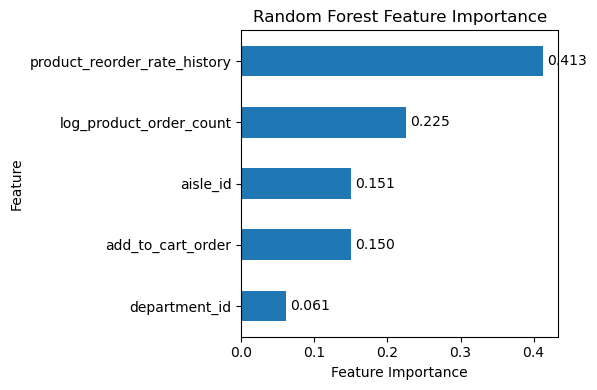

In [241]:
#Feature Importances Graph for Random Forest
import pandas as pd
import matplotlib.pyplot as plt

#get fitted feature names after preprocessing
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

#get fitted random forest model
rf_model = best_rf.named_steps['rf']

#create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

#combine one-hot encoded features back into original variables
importance_df['Feature'] = (
    importance_df['Feature']
        .str.replace(r'^numeric__', '', regex=True)
        .str.replace(r'^categorical__aisle_id.*', 'aisle_id', regex=True)
        .str.replace(r'^categorical__department_id.*', 'department_id', regex=True)
)

#sum importance values for grouped dummy variables
importance_summary = (
    importance_df
        .groupby('Feature', as_index=False)['Importance']
        .sum()
        .sort_values('Importance')
)

#plot aggregated feature importances
ax = importance_summary.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False,
    figsize=(6, 4)
)

#add labels to each bar
ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [140]:
# old feature importance without redo onehot encode
# #feature importances graph
# import pandas as pd
# import matplotlib.pyplot as plt

# #get fitted feature names after preprocessing
# feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

# #get fitted random forest
# rf_model = best_rf.named_steps['rf']

# importance = pd.Series(
#     rf_model.feature_importances_,
#     index=feature_names
# ).sort_values()

# #SHOW ONLY TOP 15 importances
# importance = importance.tail(15)

# ax = importance.plot(kind='barh')

# # add labels to each bar
# ax.bar_label(
#     ax.containers[0],
#     fmt='%.3f',
#     padding=3
# )

# plt.xlabel("Feature Importance")
# plt.title("Random Forest Feature Importance")
# plt.show()

## !Week 8 - K-Nearest Neighbors / Distance Metrics



- remember X_train is only 20k rows, easier compute for "dense" preprocessor, SVM, etc. 
- week 4 ALREADY calculated log of training set only TO PREVENT LEAKAGE, don't need to redo X_train, y_train, etc.
- using week 4 -> X = add to cart order, product order count, product reorder rate history, aisle id, department id
### USING linregdf
- y = 'reordered' (remember 0.59% = 1 anyway )

In [101]:
#no one single df, used train_df and test_df
train_df


,product_id,add_to_cart_order,aisle_id,department_id,reordered,product_order_count,product_reorder_sum,product_reorder_rate,product_order_count_history,product_reorder_sum_history,product_reorder_rate_history,log_product_order_count
0,38596,17,108,16,0,3230,1126,0.348607,3229,1126,0.348715,8.080237
1,48775,14,83,4,1,12541,6361,0.507216,12540,6360,0.507177,9.436759
2,14129,2,69,15,0,7003,3642,0.520063,7002,3642,0.520137,8.854094
3,25695,4,14,20,1,327,220,0.672783,326,219,0.671779,5.789960
4,8440,15,45,19,1,91,22,0.241758,90,21,0.233333,4.510860
...,...,...,...,...,...,...,...,...,...,...,...,...
27055279,32747,8,84,16,1,7298,5465,0.748835,7297,5464,0.748801,8.895356
27055280,25647,20,83,4,0,4215,1983,0.470463,4214,1983,0.470574,8.346405
27055281,12916,2,77,7,0,10510,5492,0.522550,10509,5492,0.522600,9.260082
27055282,10132,2,21,16,1,14992,10561,0.704442,14991,10560,0.704423,9.615272


In [89]:
#make preprocessor "dense" to handle sparse error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#separate preprocessor specifically for KNN
knn_preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ), categorical_features)
])

In [122]:
#1) KNN classifier +hyperparameter tuning        (2min runtime)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

results = []    #list of results per distance metric

#compare 3 distance metrics
metrics = {
    "Manhattan": ("minkowski", 1),       #key is name, value is tuple
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

#loop for each metric
for name, (metric, p) in metrics.items():

    knn = Pipeline([
        ('preprocessor', knn_preprocessor),
        ('knn', KNeighborsClassifier(
            metric=metric,
            p=p
        ))
    ])

    param_dist = {
        'knn__n_neighbors': [3, 5, 10, 15, 20, 30, 50],
        'knn__weights': ['uniform', 'distance']
    }

    #create randomized search CV
    knn_search = RandomizedSearchCV(
        knn,
        param_distributions=param_dist,
        n_iter=5,
        cv=5,
        scoring='roc_auc',
        random_state=0,
        n_jobs=-1
    )

    #fit model
    knn_search.fit(X_train, y_train)

    #predictions
    y_pred = knn_search.best_estimator_.predict(X_test)
    y_prob = knn_search.best_estimator_.predict_proba(X_test)[:, 1]

    #results
    results.append({
        'Distance': name,
        'Best K': knn_search.best_params_['knn__n_neighbors'],
        'Weights': knn_search.best_params_['knn__weights'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_prob)
    })

knn_results = pd.DataFrame(results)

knn_results

,Distance,Best K,Weights,Accuracy,Precision,Recall,F1,ROC AUC
0,Manhattan,30,distance,0.61785,0.647507,0.757625,0.698251,0.625381
1,Euclidean,30,distance,0.61765,0.647793,0.755740,0.697616,0.626919
2,Minkowski (p=3),30,distance,0.61825,0.648561,0.754969,0.697732,0.627306


- so this displays the best parameters for each different distance model

In [123]:
# ==========================================
# 1B) Table of ROC-AUC and F1 vs. K

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# values of k to test
k_values = [3, 5, 10, 15, 20, 30, 50]

# distance metrics to compare
metrics = {
    "Manhattan": ("minkowski", 1),
    "Euclidean": ("minkowski", 2),
    "Minkowski (p=3)": ("minkowski", 3)
}

plot_results = []

# test every distance metric and k value
for distance_name, (metric, p) in metrics.items():
    
    for k in k_values:
        knn = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(
                n_neighbors=k,
                weights='distance',
                metric=metric,
                p=p
            ))
        ])

        # fit model
        knn.fit(X_train, y_train)

        # predicted classes and probabilities
        y_pred = knn.predict(X_test)
        y_prob = knn.predict_proba(X_test)[:, 1]

        # save results
        plot_results.append({
            'Distance': distance_name,
            'K': k,
            'F1': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_prob)
        })

knn_plot_results = pd.DataFrame(plot_results)

knn_plot_results.sort_values(by='ROC-AUC', ascending=False)

,Distance,K,F1,ROC-AUC
20,Minkowski (p=3),50,0.705185,0.632879
13,Euclidean,50,0.703743,0.632335
6,Manhattan,50,0.702543,0.631249
19,Minkowski (p=3),30,0.698361,0.628908
12,Euclidean,30,0.697647,0.628786
5,Manhattan,30,0.697120,0.627287
18,Minkowski (p=3),20,0.694218,0.626207
11,Euclidean,20,0.694635,0.625560
4,Manhattan,20,0.693121,0.624179
10,Euclidean,15,0.687500,0.621918


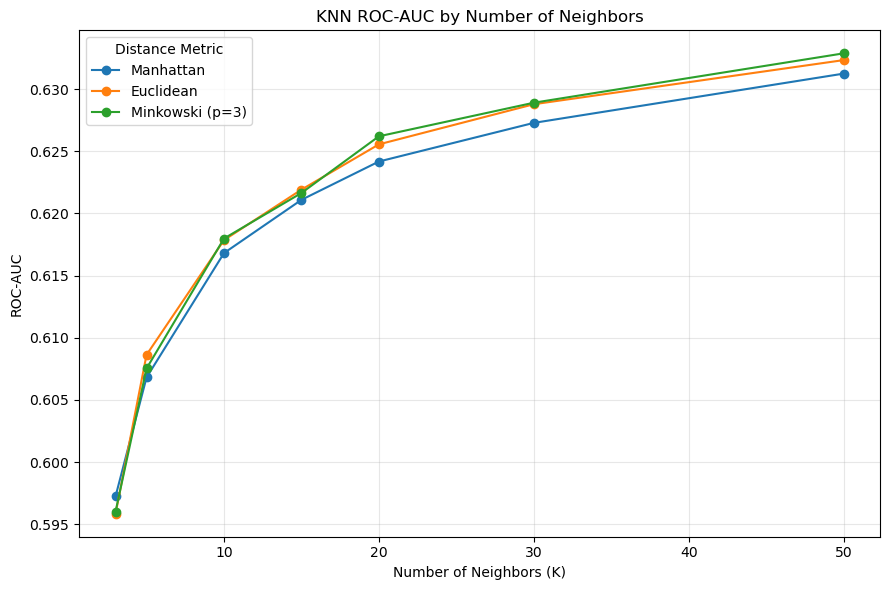

In [124]:
#ROC-AUC vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['ROC-AUC'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('ROC-AUC')
plt.title('KNN ROC-AUC by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

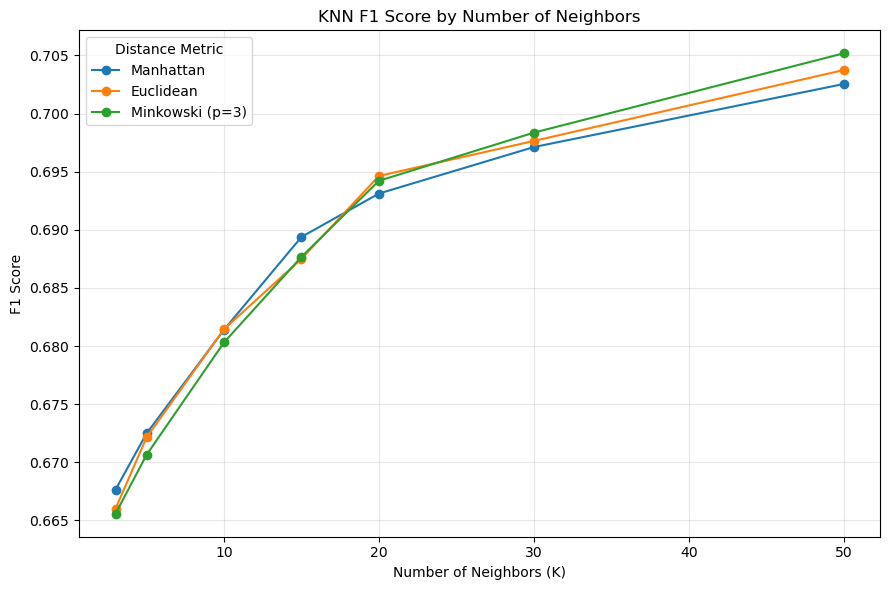

In [125]:
#F1 Score vs k Plot
plt.figure(figsize=(9, 6))

for distance_name in metrics.keys():

    metric_results = knn_plot_results[
        knn_plot_results['Distance'] == distance_name
    ]

    plt.plot(
        metric_results['K'],
        metric_results['F1'],
        marker='o',
        label=distance_name
    )

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('F1 Score')
plt.title('KNN F1 Score by Number of Neighbors')
plt.legend(title='Distance Metric')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Week 9 - Gradient Boost
- include learning rate, number of estimators, tree depth, regularization


In [126]:
#gradient boost classification                      (2 min runtime)
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

gb = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=0))
])

#make params
param_dist = {
    'gb__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'gb__n_estimators': [100, 200, 300, 400],
    'gb__max_depth': [2, 3, 5],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 5, 10]
}

#make RS-CV estimator
gb_search = RandomizedSearchCV(
    gb,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=0,
    n_jobs=-1
)

#fit search
gb_search.fit(X_train, y_train)

#create variable for model with BEST parameters
best_gb = gb_search.best_estimator_
print('best parameters', gb_search.best_params_)

#predict using X_test
y_pred_gb = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

#metrics
print("===== Gradient Boosting =====")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_gb))

best parameters {'gb__n_estimators': 200, 'gb__min_samples_split': 10, 'gb__min_samples_leaf': 2, 'gb__max_depth': 5, 'gb__learning_rate': 0.2}
===== Gradient Boosting =====
Accuracy : 0.63395
Precision: 0.649364915894267
Recall   : 0.8103152844413982
F1 Score : 0.7209665739223234
ROC AUC  : 0.6593615150159433


- analysis BETTER GB ROC value here 0.659 vs KNN 0.632
- less precision 0.649, more recall 0.810

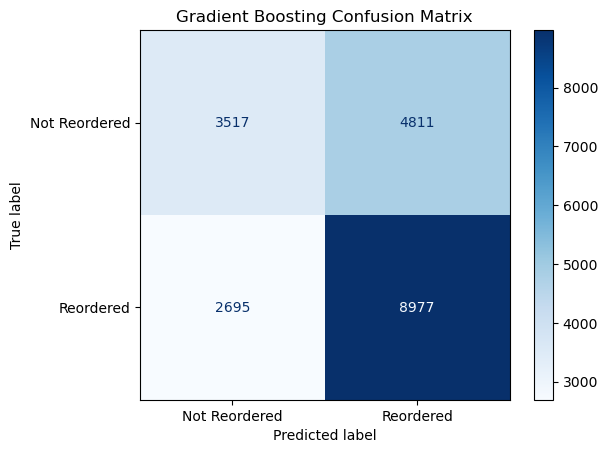

In [127]:
#1B) GB Confusion Matrix for test set
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Reordered', 'Reordered']
)

cm_display.plot(cmap='Blues')

plt.title("Gradient Boosting Confusion Matrix")
plt.show()

- INTERPRET
- incorrect predict pos 4811, incorrect predict neg 2695

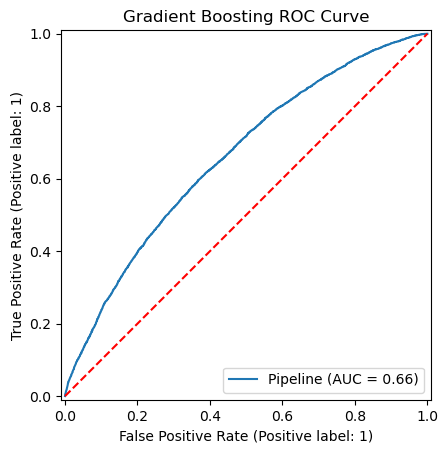

In [128]:
#1C) Plot ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_gb,
    X_test,
    y_test
)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("Gradient Boosting ROC Curve")
plt.show()

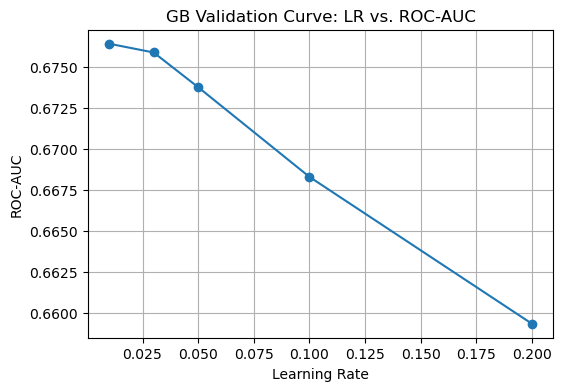

In [129]:
#1D) Validation curve: ROC-AUC vs Learning Rate

learning_rates = [0.01, 0.03, 0.05, 0.1, 0.2]
auc_scores = []

#get fitted Gradient Boosting model from pipeline
best_gb_model = best_gb.named_steps['gb']

for lr in learning_rates:

    gb = Pipeline([
        ('preprocessor', preprocessor),
        ('gb', GradientBoostingClassifier(
            learning_rate=lr,
            n_estimators=best_gb_model.n_estimators,
            max_depth=best_gb_model.max_depth,
            min_samples_split=best_gb_model.min_samples_split,
            min_samples_leaf=best_gb_model.min_samples_leaf,
            subsample=best_gb_model.subsample,
            max_features=best_gb_model.max_features,
            random_state=0
        ))
    ])

    gb.fit(X_train, y_train)

    #Predict using X_test
    y_prob = gb.predict_proba(X_test)[:, 1]

    #Save ROC-AUC
    auc_scores.append(
        roc_auc_score(y_test, y_prob)
    )

#Plot validation curve
plt.figure(figsize=(6, 4))
plt.plot(learning_rates, auc_scores, marker='o')

plt.xlabel("Learning Rate")
plt.ylabel("ROC-AUC")
plt.title("GB Validation Curve: LR vs. ROC-AUC")

plt.grid(True)
plt.show()

- here best LR is 0.2

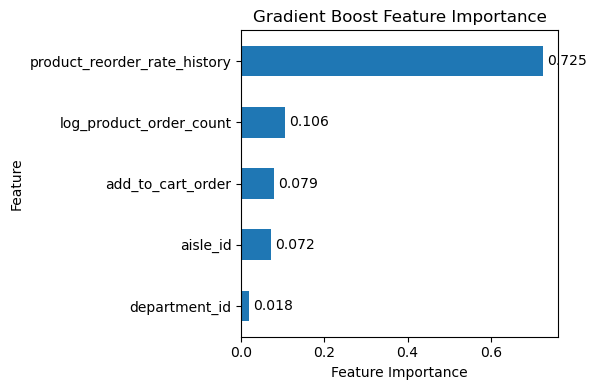

In [238]:
#1E) Feature Importance Graph for GB

import pandas as pd
import matplotlib.pyplot as plt

#get transformed feature names
feature_names = best_gb.named_steps['preprocessor'].get_feature_names_out()

#create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_gb_model.feature_importances_
})

#combine one-hot encoded features
importance_df['Feature'] = (
    importance_df['Feature']
        .str.replace(r'^numeric__', '', regex=True)
        .str.replace(r'^categorical__aisle_id.*', 'aisle_id', regex=True)
        .str.replace(r'^categorical__department_id.*', 'department_id', regex=True)
)

#sum importances for duplicate feature names
importance_summary = (
    importance_df
        .groupby('Feature', as_index=False)['Importance']
        .sum()
        .sort_values('Importance')
)

#plot aggregated feature importances
ax = importance_summary.plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False,
    figsize=(6,4)
)

ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=3
)

plt.xlabel("Feature Importance")
plt.title("Gradient Boost Feature Importance")
plt.tight_layout()
plt.show()

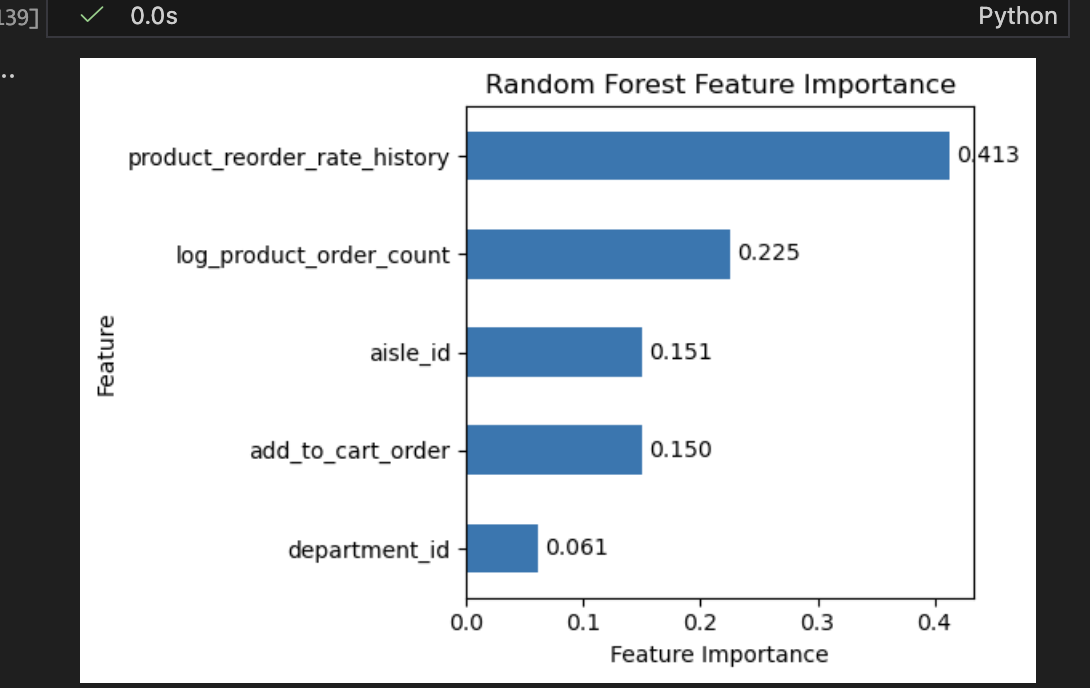

- analysis DIFFERENT from random forest
- rf reorder rate = 0.413
- rf order count = 0.225


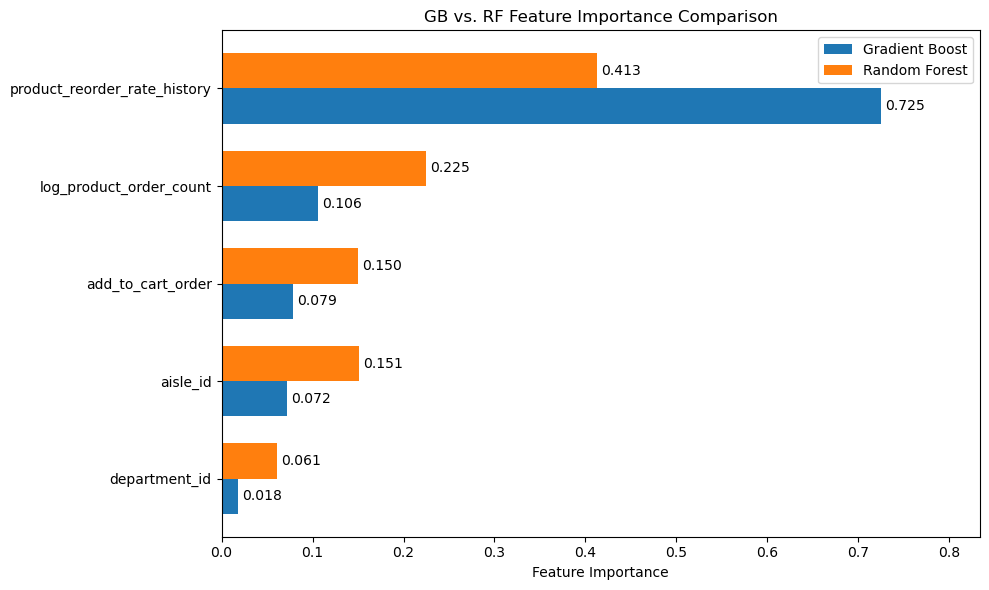

In [244]:
#FEATURE IMPORTANCE COMPARISON H-BAR chart      use figure
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Feature-importance values
importance_df = pd.DataFrame({
    "Feature": [
        "product_reorder_rate_history",
        "log_product_order_count",
        "add_to_cart_order",
        "aisle_id",
        "department_id"
    ],
    "Gradient Boost": [0.725, 0.106, 0.079, 0.072, 0.018],
    "Random Forest": [0.413, 0.225, 0.150, 0.151, 0.061]
})

# Optional: order features by average importance
importance_df["Average"] = importance_df[
    ["Gradient Boost", "Random Forest"]
].mean(axis=1)

importance_df = importance_df.sort_values("Average", ascending=True)

y = np.arange(len(importance_df))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(10, 6))

bars_gb = ax.barh(
    y - bar_height / 2,
    importance_df["Gradient Boost"],
    height=bar_height,
    label="Gradient Boost"
)

bars_rf = ax.barh(
    y + bar_height / 2,
    importance_df["Random Forest"],
    height=bar_height,
    label="Random Forest"
)

ax.set_yticks(y)
ax.set_yticklabels(importance_df["Feature"])
ax.set_xlabel("Feature Importance")
ax.set_title("GB vs. RF Feature Importance Comparison")
ax.legend()

ax.bar_label(bars_gb, fmt="%.3f", padding=3)
ax.bar_label(bars_rf, fmt="%.3f", padding=3)

ax.set_xlim(
    0,
    importance_df[["Gradient Boost", "Random Forest"]].max().max() * 1.15
)

plt.tight_layout()
plt.show()

Best number of trees: 185
Best validation ROC-AUC: 0.7810488480498282


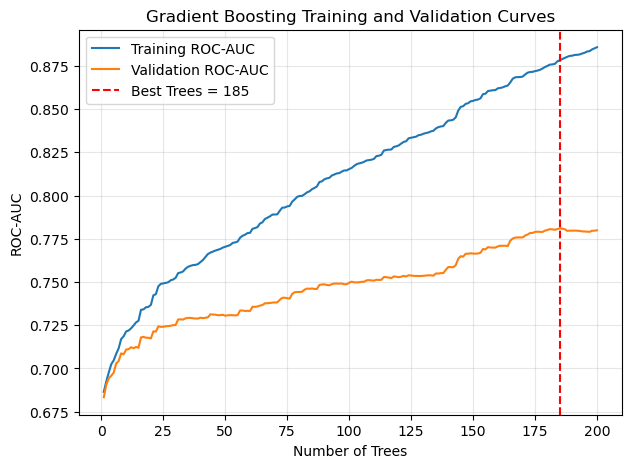

In [228]:
#Training and Validation ROC-AUC vs Number of Trees

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

#split training data again into train and validation
X_gb_train, X_val, y_gb_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=0,
    stratify=y_train
)
#copy best pipeline model
gb_curve = clone(best_gb)

#fit pipeline
gb_curve.fit(X_gb_train, y_gb_train)

#get gradient boosting model inside pipeline
gb_model = gb_curve.named_steps['gb']

#get scaled training and validation data
X_gb_train_scaled = gb_curve.named_steps['preprocessor'].transform(X_gb_train)  #remember best_gb is pipeline, so convert first
X_val_scaled = gb_curve.named_steps['preprocessor'].transform(X_val)

train_auc = []
val_auc = []

#find predictions after each new tree
for train_prob, val_prob in zip(
    gb_model.staged_predict_proba(X_gb_train_scaled),
    gb_model.staged_predict_proba(X_val_scaled)
):

    train_auc.append(
        roc_auc_score(y_gb_train, train_prob[:,1])
    )

    val_auc.append(
        roc_auc_score(y_val, val_prob[:,1])
    )

#number of trees
trees = range(1, len(train_auc) + 1)

#find tree with highest validation ROC-AUC
best_tree = np.argmax(val_auc) + 1
best_val_auc = max(val_auc)

print("Best number of trees:", best_tree)
print("Best validation ROC-AUC:", best_val_auc)


#PART 2 

#plot training and validation curves
plt.figure(figsize=(7,5))
plt.plot(trees, train_auc, label='Training ROC-AUC')
plt.plot(trees,val_auc,label='Validation ROC-AUC')

plt.axvline(    #vertical line for tree number w/best score
    best_tree,
    color='red',
    linestyle='--',
    label=f'Best Trees = {best_tree}'
)

plt.xlabel("Number of Trees")
plt.ylabel("ROC-AUC")
plt.title("Gradient Boosting Training and Validation Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Week 10 - Clustering 1
- include k-means: elbow method, Silhouette score, feature scaling, distance metrics


CHANGE X to not include binary 

In [157]:
linregdf['log_total_orders'] = np.log1p(linregdf['total_orders'])

X = linregdf[
    [
        'reorder_rate',
        'avg_cart_pos',
        'log_total_orders'
    ]
]
X.head()

,reorder_rate,avg_cart_pos,log_total_orders
0,0.614627,5.845954,7.564757
1,0.138298,10.138298,4.553877
2,0.738516,6.374558,5.648974
3,0.458689,9.472934,5.863631
4,0.625000,6.375000,2.833213


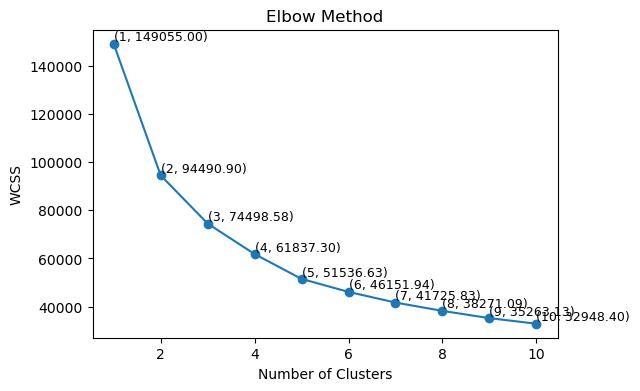

In [158]:
#1) Clustering 1 
 
# X_scaled features First 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#A) Elbow Method (find best # of clusters)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []   #empty list of within cluster SS

for k in range(1,11):   #use k-values of 1 TILL 10
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10        #num of times k-means runs with diff centroid seeds
    )
    #fit model
    kmeans.fit(X_scaled)
    #append list 
    wcss.append(kmeans.inertia_)    #.inertia_ FINDS WCSS

#B) plot num of clusters vs. WCSS 
plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

#Loop only to place the text labels
for i, j in zip(range(1,11), wcss):
    plt.text(i, j, f'({i}, {j:.2f})', ha='left', va='bottom', fontsize=9)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [159]:
#2) Silhouette Score        (2min runtime)
from sklearn.metrics import silhouette_score

scores_list = [] #empty list

#loop for each k
for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0
    )
    #for each sample, LABEL in a cluster
    labels = kmeans.fit_predict(X_scaled)       #fit and predict in 1 step
    scores_list.append(silhouette_score(X_scaled, labels))

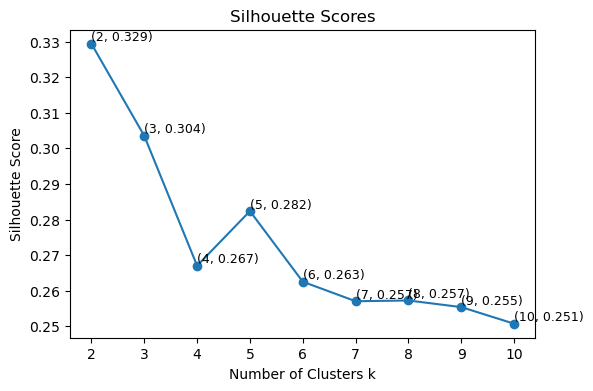

In [160]:
#plot
plt.figure(figsize=(6,4))
plt.plot(range(2,11),scores_list, marker='o')

#Loop only to place the text labels
for i, j in zip(range(2,11), scores_list):
    plt.text(i, j, f'({i}, {j:.3f})', ha='left', va='bottom', fontsize=9)

plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters k')
plt.ylabel('Silhouette Score')
plt.show()

In [249]:
#3) Best Clustering K-Means Model       use figure maybe

kmeans = KMeans(
    init = 'k-means++',
    n_clusters=3,
    random_state=0,
    n_init=10
)

#assign cluster label to each product
linregdf['Bestmodel_Cluster'] = kmeans.fit_predict(X_scaled)

#analyze clusters
kmeans_clustersummary = (
    linregdf
    .groupby('Bestmodel_Cluster')
    .agg(
        Product_Count=('product_id', 'count'),
        Avg_Reorder_Rate=('reorder_rate', 'mean'),
        Avg_Cart_Position=('avg_cart_pos', 'mean'),
        Avg_Total_Orders=('total_orders', 'mean'),
        Median_Total_Orders=('total_orders', 'median')
    )
    .round(2)
)

kmeans_clustersummary

,Product_Count,Avg_Reorder_Rate,Avg_Cart_Position,Avg_Total_Orders,Median_Total_Orders
Bestmodel_Cluster,,,,,
0,22737,0.53,8.63,1436.14,300.0
1,13960,0.23,7.37,32.64,18.0
2,12988,0.24,11.86,54.65,25.0


- analysis 
- cluster 0 shows highly popular avg total orders 1436, frequent reorder (staples bananas, eggs, etc)
- cluster 1 earlier cart position, cluster 2 later
- NOTE MEDIAN total orders cluster 0 is 300 so extremely R skewed (few products have 1000s of orders)

chat report


K-means clustering identified three distinct product groups. Cluster 0 contained the largest number of products (22,737) and represented highly popular items, exhibiting the highest average reorder rate (53%) and substantially greater purchase volume (1,436 average orders) than the other clusters. Clusters 1 and 2 exhibited similar reorder rates (approximately 23–24%) and relatively low purchase volumes, but differed in average cart position. Products in Cluster 1 tended to be added earlier in the shopping process, whereas Cluster 2 products were generally added later. These findings suggest that product popularity and customer purchasing behavior naturally separate products into high-demand staples and lower-demand specialty items.

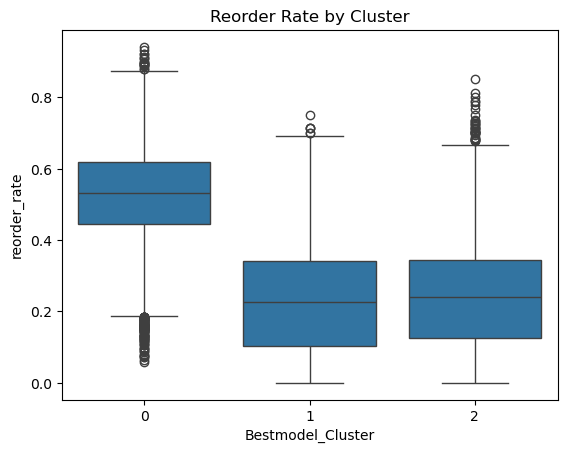

In [250]:
#box plot clusters vs. reorder rate
import seaborn as sns

sns.boxplot(
    data=linregdf,
    x='Bestmodel_Cluster',
    y='reorder_rate'
)
plt.title("Reorder Rate by Cluster")
plt.show()


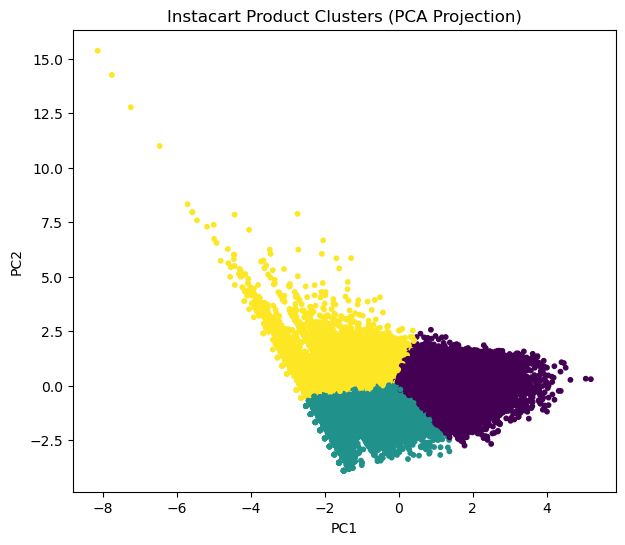

In [243]:
#4) PCA for Clustering
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

#scale features
X_pca = pca.fit_transform(X_scaled) #array only 2 components 

#Plot pca
plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],     #all rows, PC 1
    X_pca[:,1],     #all rows, PC 2
    c=linregdf['Bestmodel_Cluster'],  #color values 
    cmap='viridis',
    s=10    #marker size
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Instacart Product Clusters (PCA Projection)')
plt.show()


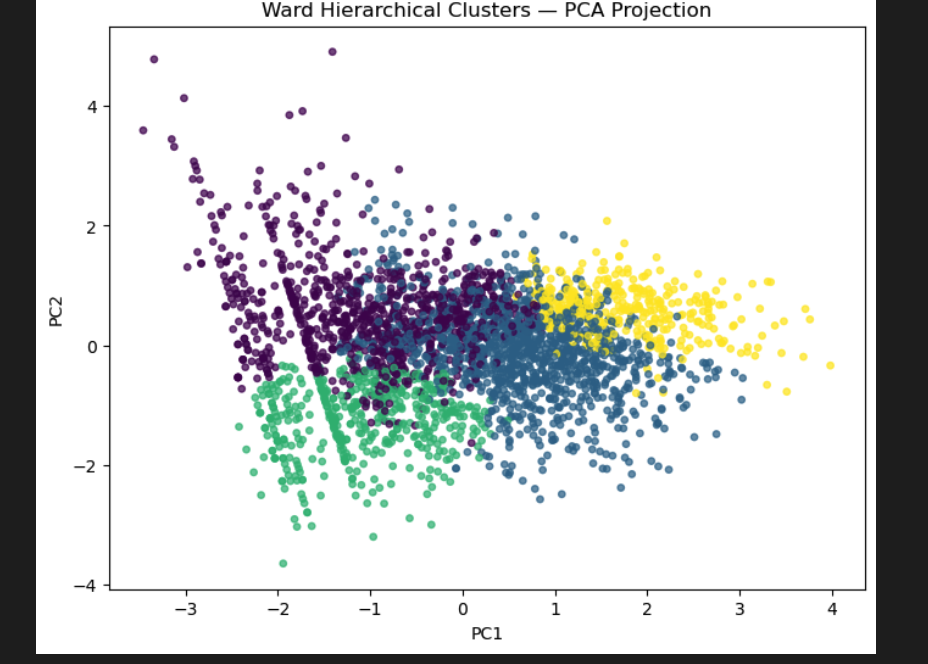

c

In [223]:
kmeans_clustersummary


,Product_Count,Avg_Reorder_Rate,Avg_Cart_Position,Avg_Total_Orders,Median_Total_Orders
Bestmodel_Cluster,,,,,
0,22737,0.53,8.63,1436.14,300.0
1,13960,0.23,7.37,32.64,18.0
2,12988,0.24,11.86,54.65,25.0


In [219]:
linregdf

,product_id,reorder_rate,avg_cart_pos,total_orders,aisle_id,department_id,position_total_interaction,Bestmodel_Cluster,log_total_orders,DBSCAN_Cluster
0,1,0.614627,5.845954,1928,61,19,11271.0,0,7.564757,0
1,2,0.138298,10.138298,94,104,13,953.0,2,4.553877,0
2,3,0.738516,6.374558,283,94,7,1804.0,0,5.648974,0
3,4,0.458689,9.472934,351,38,1,3325.0,0,5.863631,0
4,5,0.625000,6.375000,16,5,13,102.0,0,2.833213,0
...,...,...,...,...,...,...,...,...,...,...
49680,49684,0.111111,4.333333,9,124,5,39.0,1,2.302585,0
49681,49685,0.122449,9.571429,49,42,1,469.0,2,3.912023,0
49682,49686,0.700787,7.433071,127,112,3,944.0,0,4.852030,0
49683,49687,0.428571,7.071429,14,41,8,99.0,1,2.708050,0


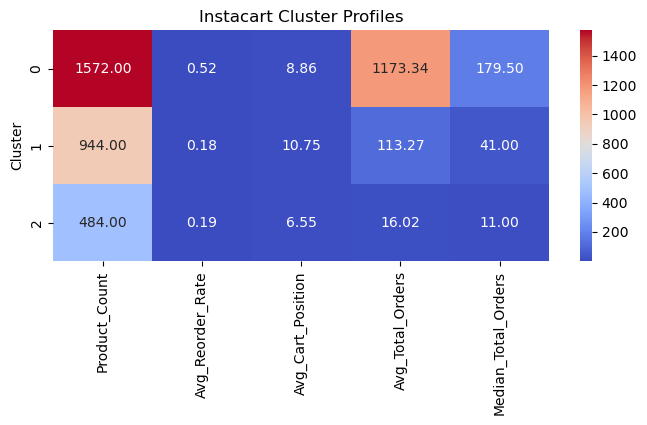

In [233]:
#INSTACART CLUSTER PROFILE HEATMAP

instacart_heat = clustersummary[
    ['Product_Count',
     'Avg_Reorder_Rate',
     'Avg_Cart_Position',
     'Avg_Total_Orders',
     'Median_Total_Orders']
]

plt.figure(figsize=(8,3))

sns.heatmap(
    instacart_heat,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Instacart Cluster Profiles')
plt.ylabel('Cluster')
plt.show()

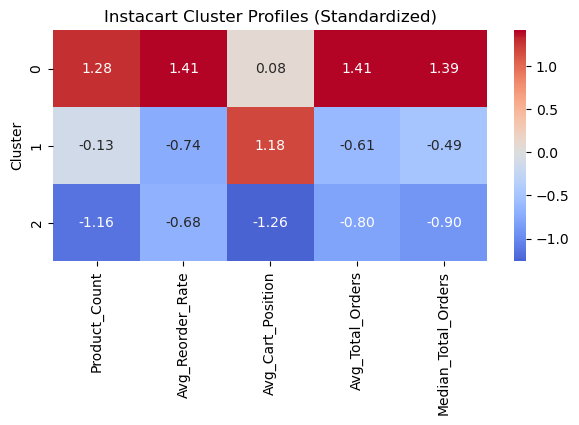

In [235]:
from sklearn.preprocessing import StandardScaler                #figure maybe

heat_scaled = pd.DataFrame(
    StandardScaler().fit_transform(instacart_heat),
    columns=instacart_heat.columns,
    index=instacart_heat.index
)

plt.figure(figsize=(7,3))

sns.heatmap(
    heat_scaled,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Instacart Cluster Profiles (Standardized)')
plt.ylabel('Cluster')
plt.show()

## Week 11 - Clustering 2
- include DBSCAN, HAC, linkage methods, dendrograms


In [170]:
#Choose best epsilon tuning             use figure maybe
from sklearn.cluster import DBSCAN

for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)

    print(
        f"eps={eps}:",
        pd.Series(labels).value_counts().sort_index().to_dict()
    )

eps=0.3: {-1: 471, 0: 49172, 1: 17, 2: 10, 3: 5, 4: 10}
eps=0.5: {-1: 63, 0: 49622}
eps=0.7: {-1: 29, 0: 49656}
eps=1.0: {-1: 17, 0: 49668}
eps=1.5: {-1: 5, 0: 49680}


In [168]:
#1) DBSCAN          useful for non-linear clusters

#model
dbscan = DBSCAN(
    eps=0.3,     #epsilon default min distance to be considered neighbor 
    min_samples=10
)

#predictions
dbscan_pred = dbscan.fit_predict(X_scaled)
dbscan_pred

#new feature that labels each row in a cluster
linregdf['DBSCAN_Cluster'] = dbscan_pred
linregdf['DBSCAN_Cluster'].sort_values(ascending=False)

22878    4
28288    4
29287    4
37586    4
41961    4
        ..
18873   -1
39951   -1
30626   -1
18875   -1
16947   -1
Name: DBSCAN_Cluster, Length: 49685, dtype: int64

In [171]:
# 1b) Num of Clusters and Noise Points
n_noise = list(dbscan_pred).count(-1)
n_clusters = linregdf['DBSCAN_Cluster'].nunique() - (1 if -1 in dbscan_pred else 0)    #since -1 present, subtract 1 from total clusters

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 5
Number of noise points: 471


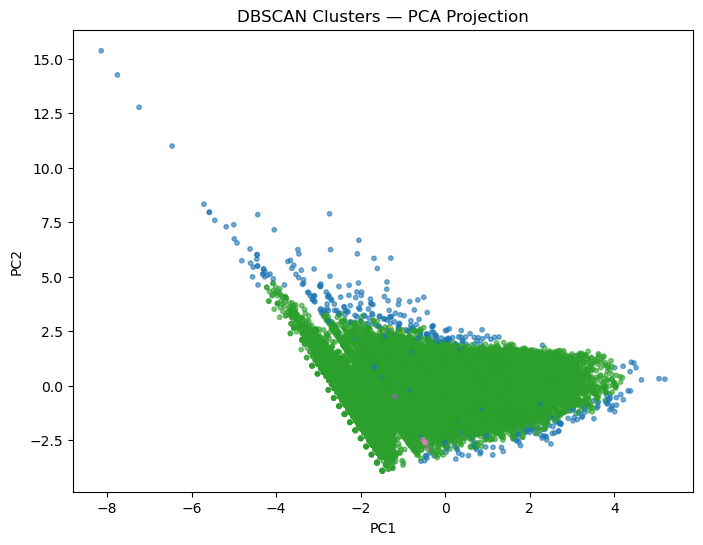

In [172]:
#1C) DBSCAN PCA plot
pca = PCA(n_components=2)
#scale
X_pca = pca.fit_transform(X_scaled)

#Plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=dbscan_pred,  #color values
    cmap = 'tab10',
    s=10,   #size of points
    alpha = 0.6
)

plt.title('DBSCAN Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

- DBSCAN not useful because one dominant cluster, the others small like 5,10,17 observations

In [174]:
#1D) Test different DBSCAN parameters       (3min runtime)          USE THIS FIGURE MAYBE

dbscan_results = []

#parameters list
eps_values = [0.2,0.3,0.4,0.5,0.7,1.0]
min_sample_values = [5,10,20]

#Double for-loop 
for eps in eps_values:
    for min_samples in min_sample_values:
        #create dbscan
        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
        )
        #predict cluster labels
        labels = dbscan.fit_predict(X_scaled)

        #size of largest non-noise cluster
        cluster_counts = pd.Series(labels)
        largest_cluster = (
            cluster_counts[cluster_counts != -1]
            .value_counts()
            .max()
            if any(cluster_counts != -1)
            else 0)

        
        #variables for how many noise and clusters
        n_noise = list(labels).count(-1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)    #since -1 present, subtract 1 from total clusters
        non_noise = labels != -1 

        #calculate silhouette score if viable
        if n_clusters >=2 and non_noise.sum() > n_clusters:     #cannot have more clusters than non_noise data points
            score = silhouette_score(
                X_scaled[non_noise],
                labels[non_noise],
            )
        else:
            score = None
        
        #append results to list FOR EACH PARAMETER trial
        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'clusters': n_clusters,
            'largest_cluster': largest_cluster,
            'noise_points': n_noise,
            'silhouette_score': score
        })

#convert results to df
dbscan_results = pd.DataFrame(dbscan_results)

#sorts so more than 1 cluster, and largest is <95% all data
dbscan_results[
    (dbscan_results['clusters'] >= 2) &
    (dbscan_results['largest_cluster'] < 0.95 * len(X_scaled))
].sort_values(
    'silhouette_score',
    ascending=False
)


,eps,min_samples,clusters,largest_cluster,noise_points,silhouette_score
2,0.2,20,7,44786,4718,-0.201063
1,0.2,10,19,47159,2161,-0.310909


- best 2 parameter combinations
- CONCLUDE DBSCAN not good fit for this
- largest cluster has like 90%+ data
- silhouette scores negative
- "BASCIALLY almost everything belongs together"

In [175]:
#2) Hierarchical Agglomerative Clustering (HAC)

#create smaller sample of only 3000 
np.random.seed(0)
sample_size = 3000

#random sample only 3000 rows
hac_sample = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False   #without replacement
)

#X matrix to use for HAC
X_hac = X_scaled[hac_sample]

In [184]:
#find best n_clusters k here 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

results = []

for k in range(2, 7):

    hac = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = hac.fit_predict(X_hac)

    results.append({
        'Clusters': k,
        'Silhouette': silhouette_score(X_hac, labels)
    })

pd.DataFrame(results) 

,Clusters,Silhouette
0,2,0.285808
1,3,0.253942
2,4,0.211828
3,5,0.207827
4,6,0.213318


In [195]:
#2B) Compare Linkage Methods
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#list of methods
linkage_methods = [
    'ward',
    'complete',
    'average',
    'single'
]

hac_results = []    #empty list

#loop over each method
for method in linkage_methods:
    #CREATE HAC MODEL HERE
    hac = AgglomerativeClustering(
        n_clusters=2,       #USED 4 bc good match dendro and tuning   
        linkage=method,
        metric='euclidean'
    )

    #find predictions
    labels = hac.fit_predict(X_hac)

    score = silhouette_score(X_hac, labels) #actual, predicted

    #append to list
    hac_results.append({
        'Linkage': method,
        'Silhouette Score': score
    })

#show results
hac_results = pd.DataFrame(hac_results)
hac_results.sort_values('Silhouette Score', ascending=False)



,Linkage,Silhouette Score
3,single,0.583828
2,average,0.466733
1,complete,0.323509
0,ward,0.285808


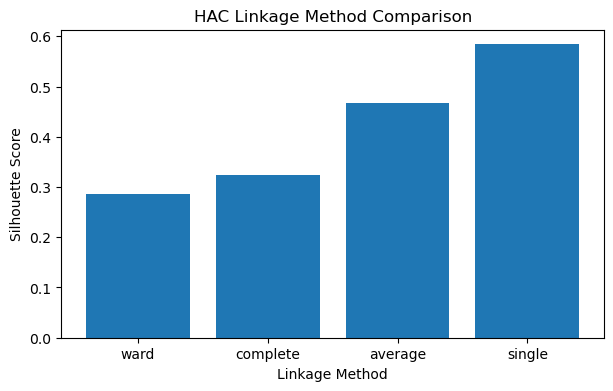

In [196]:
#2C) Plot linkage vs. sil score 
plt.figure(figsize=(7,4))

plt.bar(
    hac_results['Linkage'],
    hac_results['Silhouette Score']
)

plt.title('HAC Linkage Method Comparison')
plt.xlabel('Linkage Method')
plt.ylabel('Silhouette Score')

plt.show()

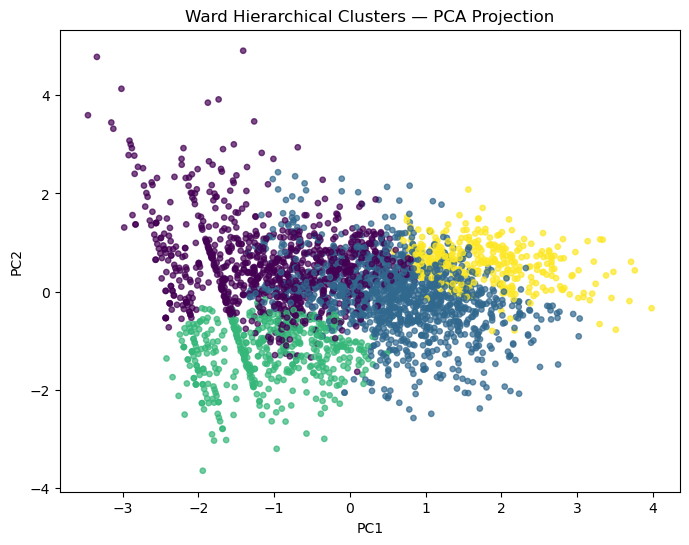

In [257]:
#2D) Fit FINAL HAC model using ward
# list = ['ward','single', 'complete', 'average'] REMEMBER others besides ward had bad PCA plots all one color

hac = AgglomerativeClustering(
    n_clusters=4,           #used 4 here instead, better visual
    linkage= 'ward'    #ward most distinct clusters
)

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)

#2E) HAC PCA Plot
X_hac_pca = PCA(n_components=2).fit_transform(X_hac)

plt.figure(figsize=(8,6))

plt.scatter(
    X_hac_pca[:, 0],
    X_hac_pca[:, 1],
    c=best_hac_labels,
    cmap='viridis',
    s=15,
    alpha=0.7
)

plt.title(f'Ward Hierarchical Clusters — PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')

plt.show()

In [200]:
#3) DENDROGRAM
from scipy.cluster.hierarchy import linkage, dendrogram

#smaller sample for dendrogram
np.random.seed(0)
my_sample = np.random.choice(
    len(X_scaled),
    size=500,
    replace=False
)

X_dendrogram = X_scaled[my_sample]

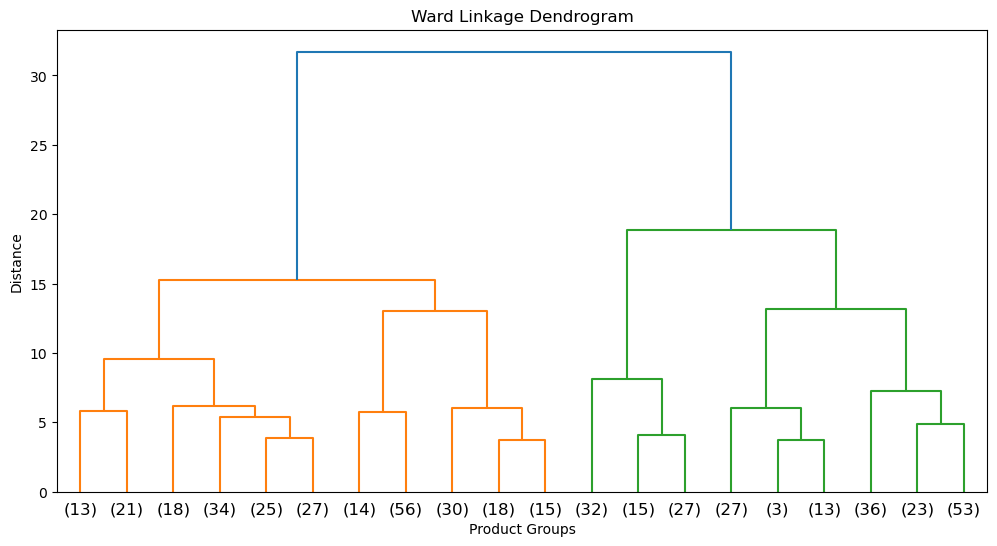

In [201]:
#3B) Ward Dendrogram

#perform HAC first to get matrix
linkage_matrix = linkage(           #output 2D array with 4 columns (cluster1, cluster2, distance_method, size of cluster)
    X_dendrogram,
    method='ward',
    metric='euclidean'
)

plt.figure(figsize=(12,6))

#create dendrogram
dendrogram(
    linkage_matrix,     #encodes the hierarchical clustering
    truncate_mode='lastp',  #last p non-singleton clusters formed in the linkage are the only non-leaf nodes
    p=20,                    
    no_labels=False
)

plt.title('Ward Linkage Dendrogram')
plt.xlabel('Product Groups')
plt.ylabel('Distance')

plt.show()

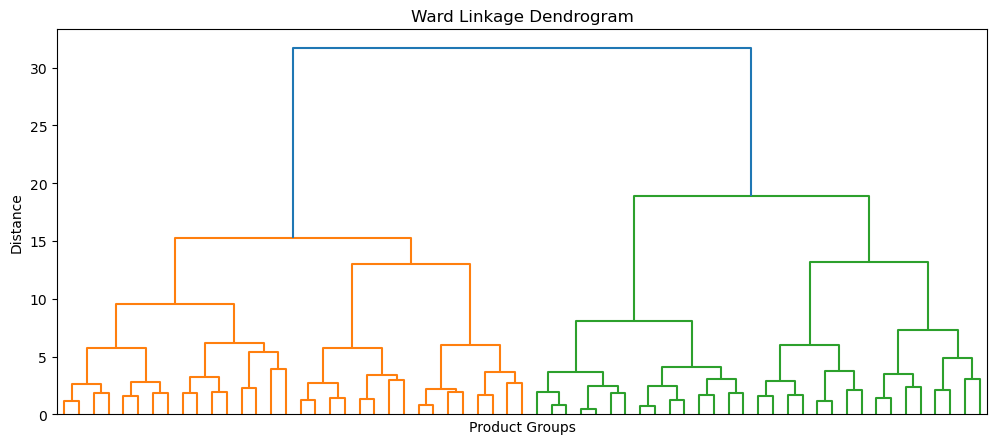

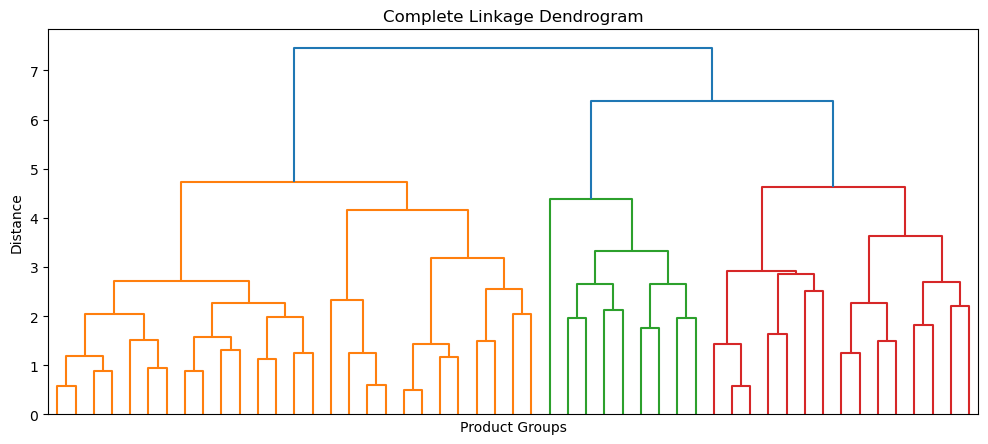

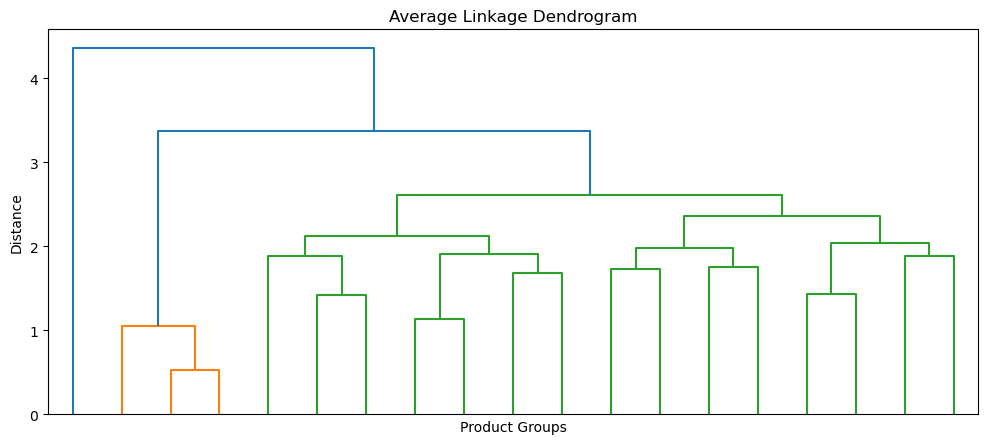

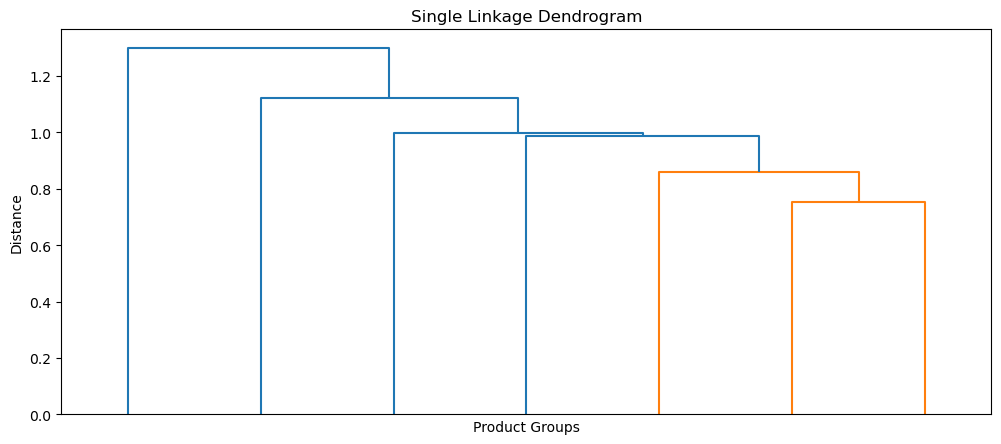

In [202]:
#3C) Compare dendrograms for each linkage method 

for method in ['ward', 'complete', 'average', 'single']:
    linkage_matrix = linkage(
        X_dendrogram,
        method=method,
        metric='euclidean'
    )

    plt.figure(figsize=(12,5))

    dendrogram(
        linkage_matrix,
        truncate_mode='level',
        p=5,
        no_labels=True
    )

    plt.title(f'{method.title()} Linkage Dendrogram')
    plt.xlabel('Product Groups')
    plt.ylabel('Distance')

    plt.show()

In [204]:
#view cluster sizes

#use best HAC model from above
hac = AgglomerativeClustering(
        n_clusters=3,       
        linkage= 'ward'    #ward most distinc clusters
    )

#find predictions 
best_hac_labels = hac.fit_predict(X_hac)


# Create dataframe for sampled products
linregdf_hac = linregdf.iloc[hac_sample].copy()

# Add cluster labels
linregdf_hac['Ward_Cluster'] = best_hac_labels

linregdf_hac['Ward_Cluster'].value_counts().sort_index()

Ward_Cluster
0    1572
1     944
2     484
Name: count, dtype: int64

In [212]:
#Ward Cluster summary 
clustersummary = (
    linregdf_hac
    .groupby('Ward_Cluster')
    .agg(
        Product_Count=('product_id', 'count'),
        Avg_Reorder_Rate=('reorder_rate', 'mean'),
        Avg_Cart_Position=('avg_cart_pos', 'mean'),
        Avg_Total_Orders=('total_orders', 'mean'),
        Median_Total_Orders=('total_orders', 'median')
    )
    .round(2)
)

clustersummary

,Product_Count,Avg_Reorder_Rate,Avg_Cart_Position,Avg_Total_Orders,Median_Total_Orders
Ward_Cluster,,,,,
0,1572,0.52,8.86,1173.34,179.5
1,944,0.18,10.75,113.27,41.0
2,484,0.19,6.55,16.02,11.0


- can compare with cluster summary for knn